<!-- @format -->

# Adult Income Predition - Deep Learning Pipeline

Xây dựng pipeline Deep Learning hoàn chỉnh cho bài toán phân loại thu nhập trên tập dữ liệu Adult Census.

**Pipeline gồm các bước:**

1. Tổng quan dữ liệu
2. Tiền xử lí dữ liệu
4. Huấn luyện mô hình
5. Đánh giá & so sánh tổng hợp


<!-- @format -->

## 1. Tổng quan dữ liệu

Phần này tóm tắt nhanh đặc trưng dữ liệu, phân phối target và các đặc trưng quan trọng nhất, giúp định hướng cho pipeline deep learning.


In [1]:
# Import thư viện và xây dựng các hàm cần thiết cho EDA
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class EDA:
    @staticmethod    
    def load_data(source: str) -> pd.DataFrame:
        """Load CSV từ URL hoặc đường dẫn local."""
        df = pd.read_csv(source)
        print("Dataset shape:", df.shape)
        print(df.head())
        return df

    @staticmethod
    def dataset_overview(df: pd.DataFrame):
        """In info, thống kê mô tả số và phân loại của dataset."""
        print("=== DataFrame Info ===")
        df.info()
        print("\n=== Numerical Summary ===")
        print(df.describe())
        print("\n=== Categorical Summary ===")
        print(df.describe(include='object'))

    @staticmethod
    def get_column_types(df: pd.DataFrame):
        """Trả về (num_cols, cat_cols) – danh sách cột số và phân loại."""
        num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        cat_cols = df.select_dtypes(include=['object']).columns.tolist()
        print("Numerical columns :", num_cols)
        print("Categorical columns:", cat_cols)
        return num_cols, cat_cols

    @staticmethod
    def check_missing_values(df: pd.DataFrame):
        """Kiểm tra NaN chuẩn và ký hiệu '?' ẩn trong dataset."""
        print("=== Missing values (NaN) ===")
        print(df.isnull().sum())
        print("\n=== '?' count per column ===")
        print((df == '?').sum())

    @staticmethod
    def inspect_categorical_values(df: pd.DataFrame, cat_cols: list, top_n: int = 10):
        """In value_counts cho từng cột phân loại trong cat_cols."""
        for col in cat_cols:
            print(f"\nColumn: {col}  |  unique: {df[col].nunique()}")
            print(df[col].astype(str).str.strip().value_counts(dropna=False).head(top_n))

    @staticmethod
    def plot_target_distribution(df: pd.DataFrame, target_col: str = 'income'):
        """In thống kê và vẽ biểu đồ phân phối biến mục tiêu."""
        print("Unique values:", df[target_col].unique())
        print("\nClass counts:")
        print(df[target_col].value_counts())
        print("\nClass percentages (%):")
        print((df[target_col].value_counts(normalize=True) * 100).round(2))

        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=target_col)
        plt.title(f'Distribution of {target_col}')
        plt.xlabel(target_col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_categorical_by_target(df: pd.DataFrame, cat_cols: list, target_col: str = 'income'):
        """Vẽ stacked bar chart chuẩn hóa cho từng cột phân loại theo target."""
        for col in cat_cols:
            crosstab_norm = pd.crosstab(df[col], df[target_col], normalize='index')
            crosstab_norm.plot(kind='bar', stacked=True, figsize=(10, 6))
            plt.title(f'{col} by {target_col} (Normalized)')
            plt.xlabel(col)
            plt.ylabel('Proportion')
            plt.xticks(rotation=45, ha='right')
            plt.legend(title=target_col)
            plt.tight_layout()
            plt.show()

    @staticmethod
    def plot_numerical_by_target(df: pd.DataFrame, num_cols: list, target_col: str = 'income'):
        """Vẽ boxplot cho tất cả các cột số theo target trong một figure."""
        n = len(num_cols)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
        if n == 1:
            axes = [axes]
        for ax, col in zip(axes, num_cols):
            sns.boxplot(data=df, x=target_col, y=col, ax=ax)
            ax.set_title(f'{col} by {target_col}')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_correlation_heatmap(df: pd.DataFrame, num_cols: list):
        """Vẽ heatmap tương quan giữa các cột số."""
        corr_matrix = df[num_cols].corr()
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Correlation Heatmap of Numerical Features')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def analyze_capital_feature(df: pd.DataFrame, col: str, target_col: str = 'income'):
        """
        Phân tích phân phối và mối liên hệ với target cho một capital feature
        (capital-gain hoặc capital-loss).
        """
        if col not in df.columns:
            print(f"Column '{col}' not found.")
            return

        zero_count = (df[col] == 0).sum()
        nonzero_pct = round((df[col] > 0).sum() / len(df) * 100, 2)

        print(f"=== {col} ===")
        print(df[col].describe())
        print(f"\nZero values : {zero_count} ({round(zero_count / len(df) * 100, 2)}%)")
        print(f"Non-zero    : {(df[col] > 0).sum()} ({nonzero_pct}%)")
        print(f"\nProportion of non-zero {col} by {target_col}:")
        print(pd.crosstab(df[target_col], df[col] > 0, normalize='index').round(3))

        # Boxplot
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.boxplot(y=df[col], ax=axes[0])
        axes[0].set_title(f'Boxplot of {col}')
        axes[0].set_ylabel(col)

        # Histogram for non-zero values
        nonzero_vals = df.loc[df[col] > 0, col]
        if len(nonzero_vals) > 0:
            sns.histplot(nonzero_vals, bins=50, ax=axes[1])
            axes[1].set_title(f'Non-zero {col} Distribution')
            axes[1].set_xlabel(col)
            axes[1].set_ylabel('Count')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def check_education_redundancy(df: pd.DataFrame):
        """Kiểm tra xem 'education' và 'educational-num' có mang cùng thông tin không."""
        if 'education' not in df.columns or 'educational-num' not in df.columns:
            print("Columns 'education' or 'educational-num' not found.")
            return
        mapping = df.groupby('education')['educational-num'].unique().reset_index()
        print("Mapping between education and educational-num:")
        print(mapping)

eda = EDA()

In [2]:
# Load dữ liệu
url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = eda.load_data(url)

Dataset shape: (48842, 15)
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-pe

In [3]:
# Tổng quan nhanh dữ liệu
eda.dataset_overview(df)
num_cols, cat_cols = eda.get_column_types(df)

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

=== Numerical Summary ===
                age       

In [4]:
# Kiểm tra missing value và giá trị bất thường
eda.check_missing_values(df)
eda.inspect_categorical_values(df, cat_cols)

=== Missing values (NaN) ===
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

=== '?' count per column ===
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Column: workclass  |  unique: 9
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay    

<!-- @format -->

**Nhận xét:** Một số cột phân loại có giá trị '?' thay cho missing value. Cần chuẩn hóa về NaN trước khi xử lý tiếp.


Unique values: ['<=50K' '>50K']

Class counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Class percentages (%):
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


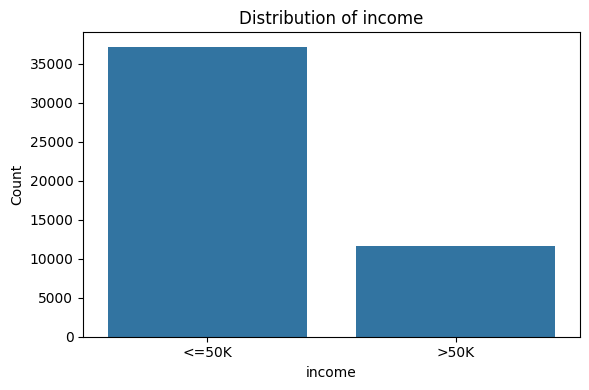

In [5]:
# Phân phối biến mục tiêu (income)
eda.plot_target_distribution(df, target_col='income')

<!-- @format -->

**Nhận xét:** Dữ liệu có mất cân bằng nhẹ giữa hai lớp thu nhập (>50K và <=50K), cần lưu ý khi đánh giá mô hình. Nhóm dự định sẽ sử dụng phương pháp SMOTE để cân bằng lại số lượng của 2 lớp này giúp tránh overfitting đối với người có income >50k.


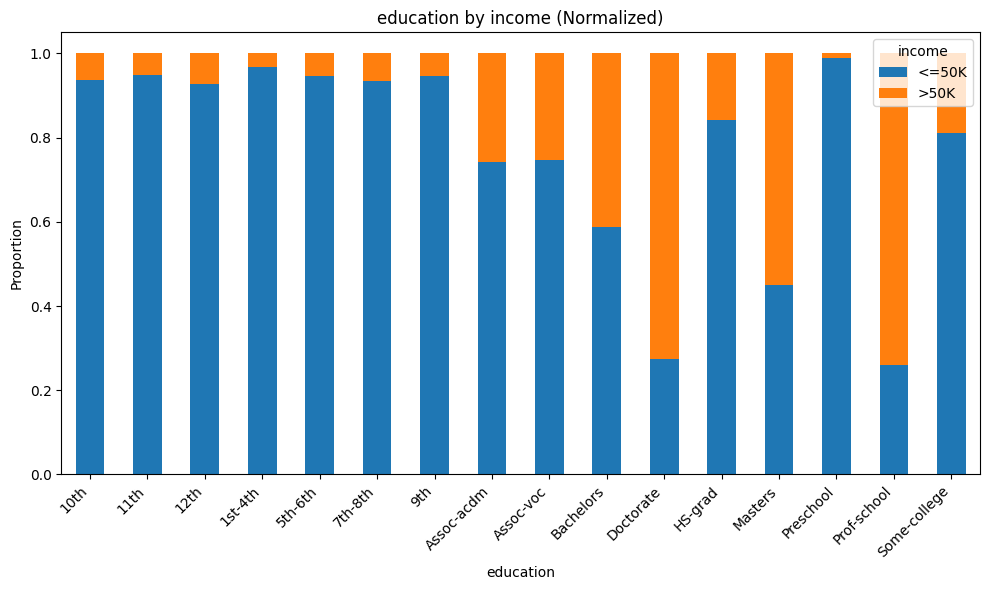

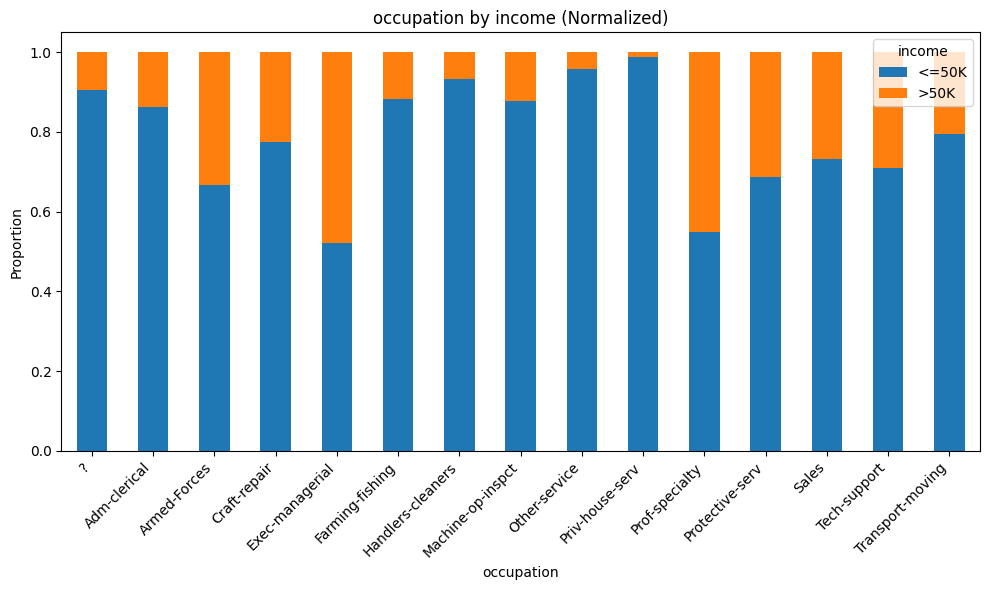

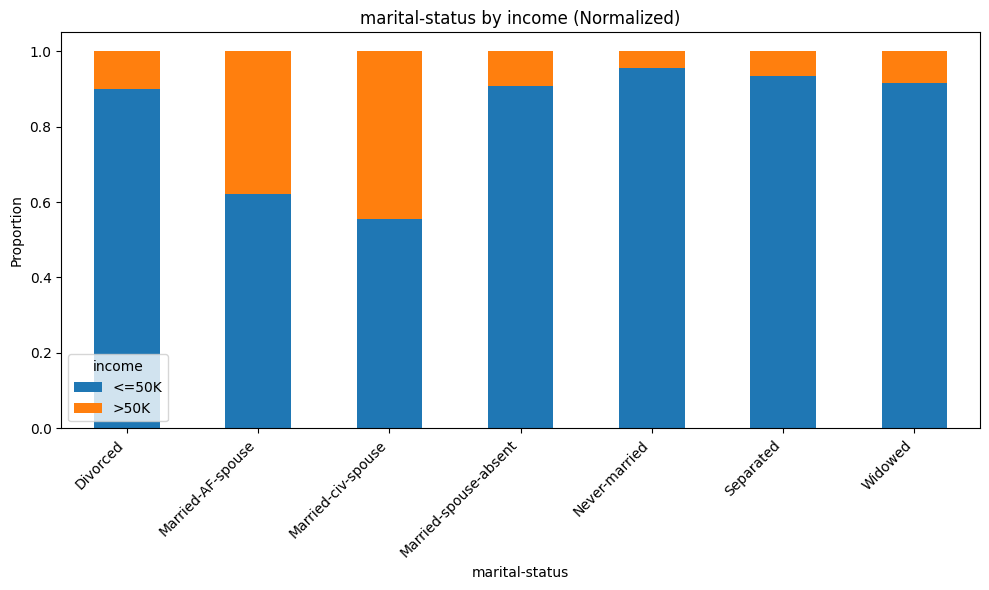

In [6]:
# Phân tích nhanh một số biến phân loại tiêu biểu
top_cat = ['education', 'occupation', 'marital-status']
eda.plot_categorical_by_target(df, top_cat, target_col='income')

<!-- @format -->

**Nhận xét:** Một số biến phân loại như education, occupation, marital-status có sự khác biệt rõ rệt giữa hai nhóm thu nhập.


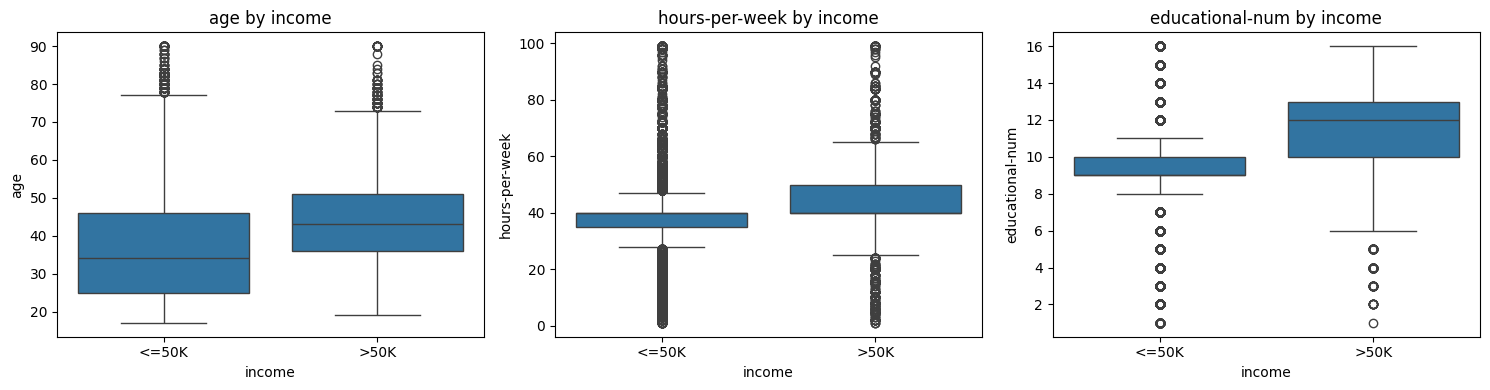

In [7]:
# Phân tích nhanh các biến số quan trọng
num_cols_sel = ['age', 'hours-per-week', 'educational-num']
eda.plot_numerical_by_target(df, num_cols_sel, target_col='income')

<!-- @format -->

**Nhận xét:** Các biến số như age, hours-per-week, educational-num đều có sự khác biệt phân phối giữa hai nhóm thu nhập.


=== capital-gain ===
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

Zero values : 44807 (91.74%)
Non-zero    : 4035 (8.26%)

Proportion of non-zero capital-gain by income:
capital-gain  False  True 
income                    
<=50K         0.958  0.042
>50K          0.787  0.213


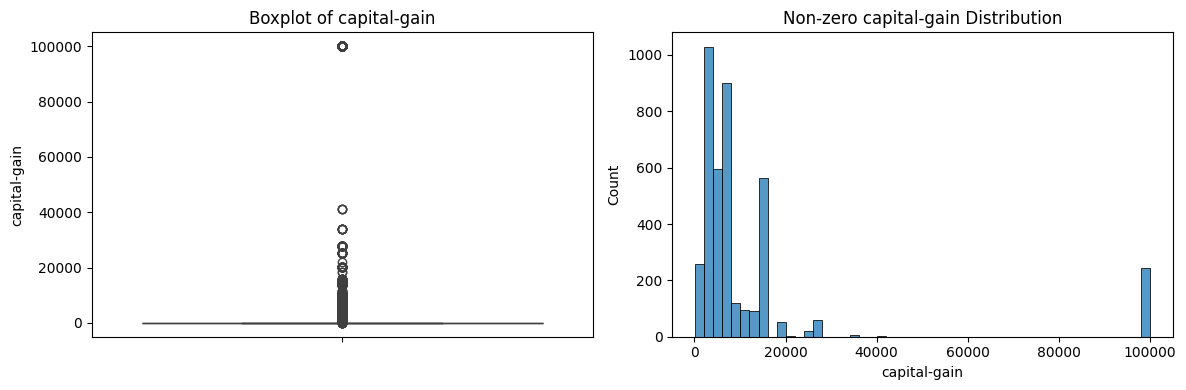

=== capital-loss ===
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Zero values : 46560 (95.33%)
Non-zero    : 2282 (4.67%)

Proportion of non-zero capital-loss by income:
capital-loss  False  True 
income                    
<=50K         0.969  0.031
>50K          0.902  0.098


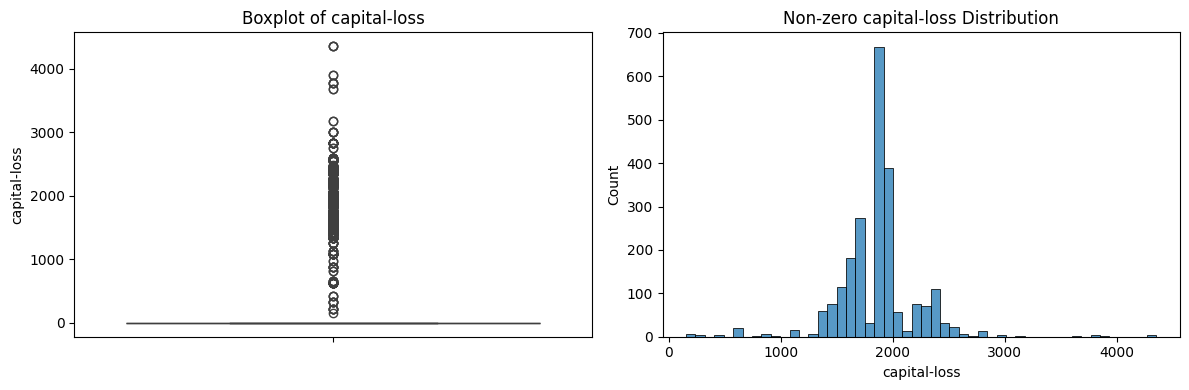

In [8]:
# Phân tích phân phối và ý nghĩa của capital-gain, capital-loss
eda.analyze_capital_feature(df, 'capital-gain', target_col='income')
eda.analyze_capital_feature(df, 'capital-loss', target_col='income')

<!-- @format -->

**Nhận xét:** Cả hai biến capital-gain và capital-loss đều có phân phối rất lệch, nhiều giá trị 0, nhưng tỷ lệ giá trị khác 0 ở nhóm >50K cao hơn đáng kể. Đây là đặc trưng hữu ích cho mô hình.


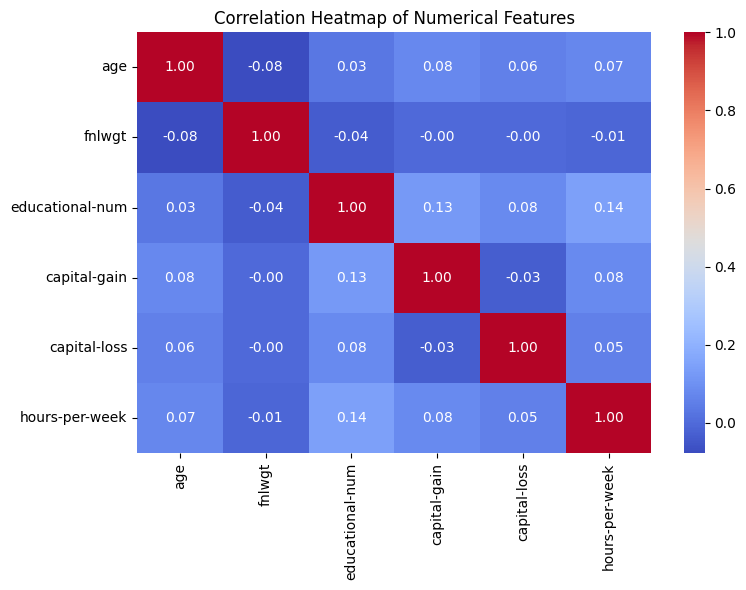

In [9]:
# Heatmap tương quan các biến số
eda.plot_correlation_heatmap(df, num_cols)

<!-- @format -->

**Nhận xét:** Các biến số không có cặp nào tương quan quá cao, có thể giữ lại hầu hết cho mô hình.


In [10]:
# Kiểm tra trùng lặp thông tin education & educational-num
eda.check_education_redundancy(df)

Mapping between education and educational-num:
       education educational-num
0           10th             [6]
1           11th             [7]
2           12th             [8]
3        1st-4th             [2]
4        5th-6th             [3]
5        7th-8th             [4]
6            9th             [5]
7     Assoc-acdm            [12]
8      Assoc-voc            [11]
9      Bachelors            [13]
10     Doctorate            [16]
11       HS-grad             [9]
12       Masters            [14]
13     Preschool             [1]
14   Prof-school            [15]
15  Some-college            [10]


<!-- @format -->

**Nhận xét:** Hai cột education và educational-num gần như mang cùng thông tin, có thể cân nhắc chỉ giữ lại một trong hai khi xây dựng mô hình.


<!-- @format -->

# 2. Tiền xử lí dữ liệu


<!-- @format -->
## 2.1. Import thư viện và hiện thực các hàm cần thiết

In [11]:
from collections import OrderedDict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


def drop_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Xóa cột không cần thiết."""
    df = df.drop(columns=columns)
    print(f"Dropped columns: {columns}")
    return df


def drop_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Xóa hàng có giá trị thiếu (NaN hoặc '?')."""
    initial_shape = df.shape
    df = df.replace('?', np.nan).dropna()
    print(f"Dropped rows with missing values: {initial_shape[0] - df.shape[0]}")
    return df


def encode_categorical(df: pd.DataFrame, cat_cols: list) -> pd.DataFrame:
    """Mã hóa cột phân loại bằng one-hot encoding."""
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print(f"Encoded categorical columns: {cat_cols}")
    return df


def map_target_variable(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """Mã hóa biến mục tiêu thành 0 và 1."""
    if target_col not in df.columns:
        print(f"Target column '{target_col}' not found.")
        return df
    df[target_col] = df[target_col].map({'<=50K': 0, '>50K': 1})
    print(f"Mapped target variable '{target_col}' to binary.")
    return df


def apply_ohe(df: pd.DataFrame, cat_cols: list, encoder: OneHotEncoder = None):
    """Chuẩn hoá các cột categories bằng OneHotEncoder"""
    if encoder is None:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded_data = encoder.fit_transform(df[cat_cols])
    else:
        encoded_data = encoder.transform(df[cat_cols])
        
    encoded_cols = encoder.get_feature_names_out(cat_cols)
    encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=df.index)
    
    # Xóa các cột gốc và nối các cột đã OHE vào
    df_out = df.drop(columns=cat_cols)
    df_out = pd.concat([df_out, encoded_df], axis=1)
    
    print(f"Applied OHE on {len(cat_cols)} columns, resulted in {len(encoded_cols)} new columns.")
    return df_out, encoder


def scale_numeric(df: pd.DataFrame, num_cols: list, scaler: StandardScaler = None):
    """Chuẩn hoá các cột số bằng StandardScaler."""
    if scaler is None:
        scaler = StandardScaler()
        df[num_cols] = scaler.fit_transform(df[num_cols])
    else:
        df[num_cols] = scaler.transform(df[num_cols])

    print(f"Scaled {len(num_cols)} numeric columns: {num_cols}")
    return df, scaler


def split_data(
    df: pd.DataFrame,
    target_col: str,
    test_size: float = 0.2,
    val_size: float = 0.1,
    random_state: int = 42
):
    """Chia dữ liệu thành tập Train / Val / Test."""
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Tách test trước
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Tách val từ phần còn lại
    # val_size tương đối so với X_temp để đảm bảo đúng tỷ lệ tuyệt đối
    relative_val_size = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=relative_val_size, random_state=random_state, stratify=y_temp
    )

    print(f"Split data → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    print(f"  Class dist (train) >50K: {y_train.mean():.1%}")
    return X_train, X_val, X_test, y_train, y_val, y_test


def apply_smote(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    sampling_strategy: str | float = 'auto',
    k_neighbors: int = 5,
    random_state: int = 42
):
    """
    Áp dụng SMOTE để cân bằng lớp trên tập train.

    Chỉ áp dụng trên tập train để tránh data leakage sang val/test.

    Parameters
    ----------
    X_train : pd.DataFrame
        Feature matrix của tập train (đã được encode & scale).
    y_train : pd.Series
        Nhãn của tập train.
    sampling_strategy : str or float, default='auto'
        - 'auto'   : cân bằng lớp thiểu số lên bằng lớp đa số.
        - float    : tỷ lệ minority/majority mong muốn (vd: 0.5 → 1:2).
    k_neighbors : int, default=5
        Số láng giềng gần nhất dùng khi sinh mẫu tổng hợp.
    random_state : int, default=42
        Seed để tái lập kết quả.

    Returns
    -------
    X_res : pd.DataFrame
        Feature matrix sau SMOTE.
    y_res : pd.Series
        Nhãn sau SMOTE.
    """
    smote = SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=k_neighbors,
        random_state=random_state
    )

    X_res, y_res = smote.fit_resample(X_train, y_train)

    # Giữ nguyên tên cột và kiểu dữ liệu
    X_res = pd.DataFrame(X_res, columns=X_train.columns)
    y_res = pd.Series(y_res, name=y_train.name)

    before = y_train.value_counts().to_dict()
    after  = y_res.value_counts().to_dict()
    print(f"SMOTE applied (strategy='{sampling_strategy}', k={k_neighbors})")
    print(f"  Before → {before}  |  total={len(y_train)}")
    print(f"  After  → {after}   |  total={len(y_res)}")
    print(f"  Class dist after SMOTE >50K: {y_res.mean():.1%}")
    return X_res, y_res

<!-- @format -->
## 2.2. Làm sạch dữ liệu

Các bước:
1. **Xoá cột dư thừa**: `education` (trùng thông tin với `educational-num`) và `fnlwgt` (trọng số thống kê, không liên quan phân loại).
2. **Xử lý giá trị `?`**: thay bằng `NaN` rồi xoá các hàng thiếu.
3. **Mã hoá biến mục tiêu**: `<=50K` → 0, `>50K` → 1.

In [12]:
df_clean = df.copy()

# 1. Xoá cột dư thừa
df_clean = drop_columns(df_clean, columns=['education', 'fnlwgt'])

# 2. Xử lý missing value ('?' → NaN → drop row)
df_clean = drop_missing_values(df_clean)

# 3. Mã hoá biến mục tiêu
df_clean = map_target_variable(df_clean, target_col='income')

print(f"\nKích thước sau làm sạch: {df_clean.shape}")
df_clean.head()

Dropped columns: ['education', 'fnlwgt']
Dropped rows with missing values: 3620
Mapped target variable 'income' to binary.

Kích thước sau làm sạch: (45222, 13)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


<!-- @format -->
## 2.3. Xác định loại đặc trưng

In [13]:
TARGET_COL = 'income'

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Bỏ target khỏi danh sách (nếu có)
if TARGET_COL in num_cols: num_cols.remove(TARGET_COL)
if TARGET_COL in cat_cols: cat_cols.remove(TARGET_COL)

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Numerical features (5): ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (7): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


<!-- @format -->
## 2.4. Chia dữ liệu Train / Val / Test

Split **trước** khi encode & scale để tránh data leakage.
Tỉ lệ: **70% train – 10% val – 20% test** (stratify theo `income`).

In [14]:
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(
    df_clean,
    target_col=TARGET_COL,
    test_size=0.2,
    val_size=0.1,
    random_state=42,
)

Split data → Train: 31654, Val: 4523, Test: 9045
  Class dist (train) >50K: 24.8%


<!-- @format -->
## 2.5. One-Hot Encoding (categorical)

Fit `OneHotEncoder` **chỉ trên train**, sau đó transform val/test bằng cùng encoder đó.

In [15]:
X_train_ohe, ohe_encoder = apply_ohe(X_train_raw, cat_cols)
X_val_ohe, _= apply_ohe(X_val_raw,   cat_cols, encoder=ohe_encoder)
X_test_ohe, _= apply_ohe(X_test_raw,  cat_cols, encoder=ohe_encoder)

print(f"\nShape sau OHE  →  train: {X_train_ohe.shape} | val: {X_val_ohe.shape} | test: {X_test_ohe.shape}")

Applied OHE on 7 columns, resulted in 82 new columns.
Applied OHE on 7 columns, resulted in 82 new columns.
Applied OHE on 7 columns, resulted in 82 new columns.

Shape sau OHE  →  train: (31654, 87) | val: (4523, 87) | test: (9045, 87)


<!-- @format -->
## 2.6. Chuẩn hoá đặc trưng số (StandardScaler)

Fit `StandardScaler` **chỉ trên train**, transform val/test.

In [16]:
X_train_sc, scaler = scale_numeric(X_train_ohe, num_cols)
X_val_sc,   _      = scale_numeric(X_val_ohe,   num_cols, scaler=scaler)
X_test_sc,  _      = scale_numeric(X_test_ohe,  num_cols, scaler=scaler)

Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


<!-- @format -->
## 2.7. Cân bằng lớp bằng SMOTE

Dữ liệu có **mất cân bằng ~24%** ở lớp `>50K`.
SMOTE sinh các mẫu tổng hợp cho lớp thiểu số **chỉ trên tập train** để tránh data leakage.

> **Lưu ý**: SMOTE phải được gọi **sau khi encode & scale** (vì cần tính khoảng cách Euclidean trên không gian số).
> Val/test **không được** áp dụng SMOTE – phải giữ nguyên phân phối thực tế.

In [17]:
X_train_sm, y_train_sm = apply_smote(
    X_train_sc,
    y_train,
    sampling_strategy='auto',   # cân bằng 50/50
    k_neighbors=5,
    random_state=42,
)

SMOTE applied (strategy='auto', k=5)
  Before → {0: 23809, 1: 7845}  |  total=31654
  After  → {0: 23809, 1: 23809}   |  total=47618
  Class dist after SMOTE >50K: 50.0%


<!-- @format -->
## 2.8. Tóm tắt kết quả preprocessing

In [18]:
summary = pd.DataFrame({
    'Split':      ['Train (sau SMOTE)', 'Val (giữ nguyên)', 'Test (giữ nguyên)'],
    'Samples':    [len(X_train_sm), len(X_val_sc), len(X_test_sc)],
    'Features':   [X_train_sm.shape[1], X_val_sc.shape[1], X_test_sc.shape[1]],
    'Class >50K': [
        f"{y_train_sm.mean():.1%}",
        f"{y_val.mean():.1%}",
        f"{y_test.mean():.1%}",
    ],
})
print(summary.to_string(index=False))
print(f"\nEncoding artifacts saved:")
print(f"  ohe_encoder : {type(ohe_encoder).__name__}")
print(f"  scaler      : {type(scaler).__name__}")

            Split  Samples  Features Class >50K
Train (sau SMOTE)    47618        87      50.0%
 Val (giữ nguyên)     4523        87      24.8%
Test (giữ nguyên)     9045        87      24.8%

Encoding artifacts saved:
  ohe_encoder : OneHotEncoder
  scaler      : StandardScaler


<!-- @format -->
# 3. Logistic Regression (Baseline)

Logistic Regression được dùng làm **baseline** để so sánh với MLP sau này.

**Lý do chọn làm baseline:**
- Đơn giản, huấn luyện nhanh, dễ giải thích
- Hiệu quả tốt với dữ liệu đã được scale và OHE
- Kết quả của nó là ngưỡng tối thiểu mà MLP cần vượt qua

<!-- @format -->
## 3.1. Huấn luyện Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
)

# Dùng X_train_sm (sau SMOTE) để train
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
)
lr_model.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained.")

Logistic Regression trained.


<!-- @format -->
## 3.2. Đánh giá trên Val set

In [20]:
y_val_pred_lr  = lr_model.predict(X_val_sc)
y_val_proba_lr = lr_model.predict_proba(X_val_sc)[:, 1]

print("=== Logistic Regression – Val Set ===")
print(classification_report(y_val, y_val_pred_lr, target_names=['<=50K', '>50K']))

val_metrics_lr = {
    'accuracy' : round(accuracy_score(y_val,  y_val_pred_lr),  4),
    'precision': round(precision_score(y_val, y_val_pred_lr),  4),
    'recall'   : round(recall_score(y_val,    y_val_pred_lr),  4),
    'f1'       : round(f1_score(y_val,        y_val_pred_lr),  4),
    'roc_auc'  : round(roc_auc_score(y_val,   y_val_proba_lr), 4),
}
print("Val metrics:", val_metrics_lr)

=== Logistic Regression – Val Set ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      3402
        >50K       0.57      0.85      0.68      1121

    accuracy                           0.80      4523
   macro avg       0.76      0.82      0.77      4523
weighted avg       0.85      0.80      0.81      4523

Val metrics: {'accuracy': 0.8041, 'precision': 0.5703, 'recall': 0.8501, 'f1': 0.6827, 'roc_auc': 0.9056}


<!-- @format -->
## 3.3. Đánh giá trên Test set

=== Logistic Regression – Test Set ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      6803
        >50K       0.57      0.84      0.68      2242

    accuracy                           0.80      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.80      0.82      9045

Test metrics: {'accuracy': 0.8045, 'precision': 0.5716, 'recall': 0.8443, 'f1': 0.6817, 'roc_auc': 0.9038}


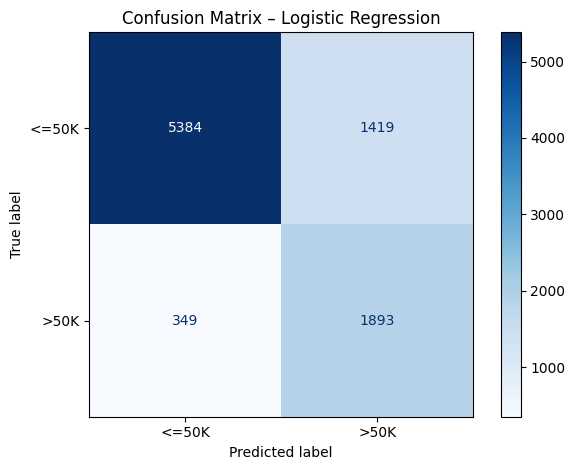

In [21]:
y_test_pred_lr  = lr_model.predict(X_test_sc)
y_test_proba_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression – Test Set ===")
print(classification_report(y_test, y_test_pred_lr, target_names=['<=50K', '>50K']))

test_metrics_lr = {
    'accuracy' : round(accuracy_score(y_test,  y_test_pred_lr),  4),
    'precision': round(precision_score(y_test, y_test_pred_lr),  4),
    'recall'   : round(recall_score(y_test,    y_test_pred_lr),  4),
    'f1'       : round(f1_score(y_test,        y_test_pred_lr),  4),
    'roc_auc'  : round(roc_auc_score(y_test,   y_test_proba_lr), 4),
}
print("Test metrics:", test_metrics_lr)

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp  = ConfusionMatrixDisplay(cm_lr, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

<!-- @format -->
# 4. MLP – Multi-Layer Perceptron

So sánh MLP với Logistic Regression baseline.

**Kiến trúc MLP:**
- Input layer → Hidden layers (BatchNorm → ReLU → Dropout) → Output (1 logit)
- Loss: `BCEWithLogitsLoss` với `pos_weight` để xử lý class imbalance còn lại trên val/test
- Optimizer: Adam + ReduceLROnPlateau scheduler
- Early stopping theo `val_loss`

<!-- @format -->
## 4.1. Import thư viện và các hàm cần thiết

In [22]:
import torch
import torch.nn as nn

from collections import OrderedDict
from torch.utils.data import Dataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

class TabularDataset(Dataset):
        """PyTorch Dataset cho dữ liệu bảng đã được encode sẵn."""

        def __init__(self, X: np.ndarray, y: np.ndarray):
            self.X = torch.tensor(X, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.long)

        def __len__(self):
            return len(self.y)

        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]
        

class MLP(nn.Module):
        """
        Multi-Layer Perceptron cho binary classification trên dữ liệu bảng.

        Parameters
        ----------
        input_dim    : Số đặc trưng đầu vào.
        hidden_dims  : Danh sách kích thước từng hidden layer, mặc định [128, 64].
        dropout      : Tỷ lệ dropout sau mỗi hidden layer.
        """

        def __init__(self, input_dim: int, hidden_dims: list = None, dropout: float = 0.2):
            super().__init__()
            if hidden_dims is None:
                hidden_dims = [128, 64]

            # Dùng OrderedDict để các lớp được thêm vào đúng thứ tự và có tên rõ ràng
            layers = OrderedDict()
            prev_dim = input_dim
            for i, h_dim in enumerate(hidden_dims):
                layers[f"linear_{i}"] = nn.Linear(prev_dim, h_dim)
                layers[f"bn_{i}"] = nn.BatchNorm1d(h_dim)
                layers[f"relu_{i}"] = nn.ReLU()
                layers[f"drop_{i}"] = nn.Dropout(dropout)

                # Cập nhật đầu vào cho lớp tiếp theo
                prev_dim = h_dim

            layers["output"] = nn.Linear(prev_dim, 1)  # 1 output: P(income > 50K) (raw logit)

            self.net = nn.Sequential(layers)

        def forward(self, x):
            # self.net trả về shape (batch, 1) → squeeze để thành (batch,)
            return self.net(x).squeeze(1)  # shape (batch,)


class DeepLearning():
    # ───────────────────────────── 1. Preprocessing ─────────────────────────────
    @staticmethod
    def group_rare_categories(
        X_train: pd.DataFrame,
        X_val: pd.DataFrame,
        X_test: pd.DataFrame,
        cat_features: list,
        threshold: float = 0.01,
    ):
        """
        Gom các category xuất hiện ít (< threshold) thành 'Other'.
        Fit trên train, transform giống nhau cho val/test.

        Returns
        -------
        (X_train, X_val, X_test, rare_mapping)
            rare_mapping : dict[str, set]  – tập hợp rare categories cho mỗi cột
        """
        X_train = X_train.copy()
        X_val = X_val.copy()
        X_test = X_test.copy()
        rare_mapping = {}
        n_train = len(X_train)

        for col in cat_features:
            freq = X_train[col].value_counts(normalize=True)
            rare_cats = set(freq[freq < threshold].index)
            rare_mapping[col] = rare_cats

            if rare_cats:
                X_train[col] = X_train[col].apply(lambda v: "Other" if v in rare_cats else v)
                X_val[col] = X_val[col].apply(lambda v: "Other" if v in rare_cats else v)
                X_test[col] = X_test[col].apply(lambda v: "Other" if v in rare_cats else v)

        n_removed = sum(len(v) for v in rare_mapping.values())
        print(f"Rare category grouping (threshold={threshold}):")
        for col, cats in rare_mapping.items():
            if cats:
                print(f"  {col}: {len(cats)} rare → 'Other'  (kept {X_train[col].nunique()} categories)")
        print(f"  Total rare categories grouped: {n_removed}")

        return X_train, X_val, X_test, rare_mapping

    @staticmethod
    def apply_quantile_binning(
        X_train: pd.DataFrame,
        X_val: pd.DataFrame,
        X_test: pd.DataFrame,
        binning_cols: tuple = ("age", "hours-per-week"),
        n_bins: int = 4,
        drop_original_numeric: bool = True,
    ):
        """
        Tạo các cột binning theo quantile dựa trên train để tránh leakage.
        """
        X_train = X_train.copy()
        X_val = X_val.copy()
        X_test = X_test.copy()
        binning_info = {}

        for col in binning_cols:
            if col not in X_train.columns:
                continue

            # Lấy bin edges từ train rồi áp dụng lại cho val/test.
            _, bins = pd.qcut(
                X_train[col],
                q=n_bins,
                retbins=True,
                duplicates="drop",
            )

            # Mở rộng biên để val/test ngoài khoảng train vẫn rơi vào bin hợp lệ.
            bins = bins.copy()
            bins[0] = -np.inf
            bins[-1] = np.inf

            new_col = f"{col}_bin"
            X_train[new_col] = pd.cut(X_train[col], bins=bins, include_lowest=True).astype(str)
            X_val[new_col] = pd.cut(X_val[col], bins=bins, include_lowest=True).astype(str)
            X_test[new_col] = pd.cut(X_test[col], bins=bins, include_lowest=True).astype(str)
            binning_info[col] = bins.tolist()

            if drop_original_numeric:
                X_train.drop(columns=[col], inplace=True)
                X_val.drop(columns=[col], inplace=True)
                X_test.drop(columns=[col], inplace=True)

        return X_train, X_val, X_test, binning_info

    @staticmethod
    def _compute_balanced_class_weights(y: np.ndarray):
        """
        Tính class weight theo công thức: w_j = N / (k * n_j).
        """
        y = np.asarray(y).astype(int)
        classes, counts = np.unique(y, return_counts=True)
        N = len(y)
        k = len(classes)
        weights = {int(cls): float(N / (k * cnt)) for cls, cnt in zip(classes, counts)}
        return weights

    @staticmethod
    def _encode_categorical_for_tabnet(
        X_train: pd.DataFrame,
        X_val: pd.DataFrame,
        X_test: pd.DataFrame,
        cat_features: list,
    ):
        """
        Encode categorical sang integer theo mapping fit trên train.
        """
        X_train = X_train.copy()
        X_val = X_val.copy()
        X_test = X_test.copy()

        cat_dims = []
        cat_maps = {}

        for col in cat_features:
            train_vals = X_train[col].astype(str)
            vocab = sorted(train_vals.unique().tolist())
            mapping = {v: i for i, v in enumerate(vocab)}
            unk_idx = len(mapping)
            cat_maps[col] = mapping
            cat_dims.append(len(mapping) + 1)  # +1 cho unknown

            X_train[col] = train_vals.map(mapping).fillna(unk_idx).astype(np.int64)
            X_val[col] = X_val[col].astype(str).map(mapping).fillna(unk_idx).astype(np.int64)
            X_test[col] = X_test[col].astype(str).map(mapping).fillna(unk_idx).astype(np.int64)

        return X_train, X_val, X_test, cat_dims, cat_maps

    @staticmethod
    def preprocess_for_dl(
        df: pd.DataFrame,
        target_col: str = "income",
        cols_to_drop: list = None,
        cat_impute_strategy: str = "most_frequent",
        test_size: float = 0.2,
        val_size: float = 0.2,
        random_state: int = 42,
        use_binning: bool = False,
        binning_cols: tuple = ("age", "hours-per-week"),
        n_bins: int = 4,
        drop_original_numeric_for_bins: bool = True,
        rare_threshold: float = 0.01,
    ):
        """
        Pipeline tiền xử lý hoàn chỉnh cho Deep Learning.
        Sử dụng One-Hot Encoding thuần cho categorical features.

        Returns
        -------
        dict với keys:
            X_train, X_val, X_test   : np.ndarray float32
            y_train, y_val, y_test   : np.ndarray int64
            num_features, cat_features : list[str]
            preprocessor             : fitted ColumnTransformer
            cat_imputer              : SimpleImputer
            input_dim                : int
        """

        # 1. Chuẩn hóa missing value
        data = df.copy()
        data.replace("?", np.nan, inplace=True)

        # 2. Loại bỏ cột dư thừa
        if cols_to_drop:
            data.drop(columns=cols_to_drop, errors="ignore", inplace=True)

        # 3. Tách X / y
        X = data.drop(columns=[target_col])
        y = data[target_col].map({"<=50K": 0, ">50K": 1}).astype(int)

        y_0 = (y == 0).sum()
        y_1 = (y == 1).sum()

        # 4. Xác định kiểu cột
        num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
        cat_features = X.select_dtypes(include=["object"]).columns.tolist()

        print(f"Numerical features ({len(num_features)}): {num_features}")
        print(f"Categorical features ({len(cat_features)}): {cat_features}")
        print(f"Encoding mode: OHE thuần")

        # 5. Split: train → (train + val) / test, rồi train → train / val
        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full,
            test_size=val_size, random_state=random_state, stratify=y_train_full,
        )

        print(f"\nTrain: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

        # 6. Impute categorical missing
        cat_imputer = SimpleImputer(strategy=cat_impute_strategy)
        X_train[cat_features] = cat_imputer.fit_transform(X_train[cat_features])
        X_val[cat_features] = cat_imputer.transform(X_val[cat_features])
        X_test[cat_features] = cat_imputer.transform(X_test[cat_features])

        # 6.1 Gom category hiếm trên categorical để giảm sparsity.
        X_train, X_val, X_test, rare_mapping = DeepLearning.group_rare_categories(
            X_train, X_val, X_test, cat_features=cat_features, threshold=rare_threshold
        )

        # 6.2 Feature engineering theo quantile binning.
        binning_info = {}
        if use_binning:
            X_train, X_val, X_test, binning_info = DeepLearning.apply_quantile_binning(
                X_train,
                X_val,
                X_test,
                binning_cols=binning_cols,
                n_bins=n_bins,
                drop_original_numeric=drop_original_numeric_for_bins,
            )
            print(f"Binning enabled for: {list(binning_info.keys())}")

        # Cập nhật kiểu cột sau các bước feature engineering.
        num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
        cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()

        # 7. ColumnTransformer: StandardScaler (num) + OHE (cat)
        cat_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), num_features),
                ("cat", cat_transformer, cat_features),
            ]
        )

        X_train_np = preprocessor.fit_transform(X_train, y_train).astype(np.float32)
        X_val_np = preprocessor.transform(X_val).astype(np.float32)
        X_test_np = preprocessor.transform(X_test).astype(np.float32)
        y_train_np = y_train.values.astype(np.int64)
        y_val_np = y_val.values.astype(np.int64)
        y_test_np = y_test.values.astype(np.int64)

        input_dim = X_train_np.shape[1]
        print(f"Input dimension: {input_dim}")
        print(f"Target distribution (train): {np.bincount(y_train_np)}")

        return {
            "X_train": X_train_np, "X_val": X_val_np, "X_test": X_test_np,
            "y_train": y_train_np, "y_val": y_val_np, "y_test": y_test_np,
            "num_features": num_features, "cat_features": cat_features,
            "preprocessor": preprocessor, "cat_imputer": cat_imputer,
            "input_dim": input_dim, "y_dist": (y_0, y_1),
            "rare_mapping": rare_mapping, "binning_info": binning_info,
        }

    @staticmethod
    def preprocess_for_tabnet(
        df: pd.DataFrame,
        target_col: str = "income",
        cols_to_drop: list = None,
        cat_impute_strategy: str = "most_frequent",
        num_impute_strategy: str = "median",
        test_size: float = 0.2,
        val_size: float = 0.2,
        random_state: int = 42,
        use_binning: bool = True,
        binning_cols: tuple = ("age", "hours-per-week"),
        n_bins: int = 4,
        drop_original_numeric_for_bins: bool = True,
        rare_threshold: float = 0.01,
    ):
        """
        Preprocessing dành riêng cho TabNet: categorical giữ dạng integer encoding,
        đồng thời trả về metadata cat_idxs/cat_dims để TabNet dùng embedding nội bộ.
        """
        data = df.copy()
        data.replace("?", np.nan, inplace=True)

        if cols_to_drop:
            data.drop(columns=cols_to_drop, errors="ignore", inplace=True)

        X = data.drop(columns=[target_col])
        if pd.api.types.is_numeric_dtype(data[target_col]):
            y = data[target_col].astype(int)
        else:
            y = data[target_col].astype(str).str.strip().map({"<=50K": 0, ">50K": 1}).astype(int)

        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full,
            y_train_full,
            test_size=val_size,
            random_state=random_state,
            stratify=y_train_full,
        )

        num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
        cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()

        if num_features:
            num_imputer = SimpleImputer(strategy=num_impute_strategy)
            X_train[num_features] = num_imputer.fit_transform(X_train[num_features])
            X_val[num_features] = num_imputer.transform(X_val[num_features])
            X_test[num_features] = num_imputer.transform(X_test[num_features])
        else:
            num_imputer = None

        if cat_features:
            cat_imputer = SimpleImputer(strategy=cat_impute_strategy)
            X_train[cat_features] = cat_imputer.fit_transform(X_train[cat_features])
            X_val[cat_features] = cat_imputer.transform(X_val[cat_features])
            X_test[cat_features] = cat_imputer.transform(X_test[cat_features])
        else:
            cat_imputer = None

        X_train, X_val, X_test, rare_mapping = DeepLearning.group_rare_categories(
            X_train, X_val, X_test, cat_features=cat_features, threshold=rare_threshold
        )

        binning_info = {}
        if use_binning:
            X_train, X_val, X_test, binning_info = DeepLearning.apply_quantile_binning(
                X_train,
                X_val,
                X_test,
                binning_cols=binning_cols,
                n_bins=n_bins,
                drop_original_numeric=drop_original_numeric_for_bins,
            )

        # Cập nhật feature lists sau feature engineering.
        num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
        cat_features = X_train.select_dtypes(include=["object"]).columns.tolist()

        X_train_enc, X_val_enc, X_test_enc, cat_dims, cat_maps = DeepLearning._encode_categorical_for_tabnet(
            X_train, X_val, X_test, cat_features=cat_features
        )

        ordered_features = num_features + cat_features
        cat_idxs = [ordered_features.index(col) for col in cat_features]

        X_train_np = np.column_stack(
            [X_train_enc[num_features].to_numpy(dtype=np.float32), X_train_enc[cat_features].to_numpy(dtype=np.float32)]
        )
        X_val_np = np.column_stack(
            [X_val_enc[num_features].to_numpy(dtype=np.float32), X_val_enc[cat_features].to_numpy(dtype=np.float32)]
        )
        X_test_np = np.column_stack(
            [X_test_enc[num_features].to_numpy(dtype=np.float32), X_test_enc[cat_features].to_numpy(dtype=np.float32)]
        )

        y_train_np = y_train.values.astype(np.int64)
        y_val_np = y_val.values.astype(np.int64)
        y_test_np = y_test.values.astype(np.int64)

        class_weights = DeepLearning._compute_balanced_class_weights(y_train_np)

        print("Encoding mode: TabNet integer categorical + internal embeddings")
        print(f"Num features: {len(num_features)} | Cat features: {len(cat_features)}")
        print(f"cat_idxs: {cat_idxs}")
        print(f"cat_dims: {cat_dims}")

        return {
            "X_train": X_train_np,
            "X_val": X_val_np,
            "X_test": X_test_np,
            "y_train": y_train_np,
            "y_val": y_val_np,
            "y_test": y_test_np,
            "num_features": num_features,
            "cat_features": cat_features,
            "ordered_features": ordered_features,
            "cat_idxs": cat_idxs,
            "cat_dims": cat_dims,
            "cat_maps": cat_maps,
            "class_weights": class_weights,
            "cat_imputer": cat_imputer,
            "num_imputer": num_imputer,
            "rare_mapping": rare_mapping,
            "binning_info": binning_info,
            "input_dim": X_train_np.shape[1],
        }


    # ───────────────────────────── 2. Dataset / DataLoader ──────────────────────
    @staticmethod
    def create_dataloaders(prep: dict, batch_size: int = 256, num_workers: int = 0):
        """
        Tạo DataLoader cho train / val / test từ output của preprocess_for_dl.
        """
        train_ds = TabularDataset(prep["X_train"], prep["y_train"])
        val_ds = TabularDataset(prep["X_val"], prep["y_val"])
        test_ds = TabularDataset(prep["X_test"], prep["y_test"])

        # shuffle=True để mỗi epoch có batch khác nhau, giúp mô hình tổng quát hơn
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

        print(f"DataLoaders created  |  batch_size={batch_size}")
        print(f"  Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")

        return train_loader, val_loader, test_loader


    # ───────────────────────────── 3. Model ─────────────────────────────────────


    # ───────────────────────────── 4. Training ──────────────────────────────────
    @staticmethod
    def train_one_epoch(model, loader, criterion, optimizer, device):
        """Chạy 1 epoch training, trả về (avg_loss, accuracy)."""
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Xoá gradients cũ trước khi backpropagation
            optimizer.zero_grad()

            # Lan truyền tiến (forward pass) để tính logits (chưa qua sigmoid)
            logits = model(X_batch)                        # shape (batch,)

            # Tính loss với BCEWithLogitsLoss (tự tích hợp sigmoid + binary cross-entropy)
            loss = criterion(logits, y_batch.float())

            # Lan truyền ngược (backward pass) để tính gradients
            loss.backward()

            # Cập nhật trọng số với optimizer
            optimizer.step()

            # Cộng dồn loss và tính accuracy trên batch
            total_loss += loss.item() * len(y_batch)

            # Dự đoán nhãn: sigmoid(logits) > 0.5 → logits > 0
            preds = (logits > 0).long()                    # sigmoid(0)=0.5 → ngưỡng 0.5
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)

        return total_loss / total, correct / total


    @staticmethod
    @torch.no_grad()
    def evaluate(model, loader, criterion, device):
        """Evaluate trên một DataLoader, trả về (avg_loss, accuracy)."""
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch.float())

            total_loss += loss.item() * len(y_batch)
            preds = (logits > 0).long()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)

        return total_loss / total, correct / total

    @staticmethod
    def train_model(
        model,
        train_loader,
        val_loader,
        epochs: int = 50,
        lr: float = 1e-3,             # Learning rate cho optimizer (Adam)
        weight_decay: float = 1e-4,   # Kĩ thuật regularization L2 giúp tránh overfitting bằng cách phạt các trọng số lớn
        patience: int = 10,           # Số epoch liên tiếp không cải thiện val_loss để dừng sớm
        device: str = None,
        use_pos_weight: bool = True,  # False khi đã dùng SMOTE (dữ liệu train đã cân bằng)
    ):
        """
        Vòng huấn luyện chính với Early Stopping theo val_loss.

        Parameters
        ----------  @staticmethod
        use_pos_weight : bool, default=True
            Có tính pos_weight để bù class imbalance hay không.
            Đặt False khi train data đã được cân bằng bằng SMOTE.

        Returns
        -------
        history : dict  (train_loss, val_loss, train_acc, val_acc theo từng epoch)
        """

        # Đưa model lên device (GPU nếu có) trước khi tạo criterion/optimizer
        model = model.to(device)

        # ── Định nghĩa Loss criterion ──────────────────────────────────────────
        if use_pos_weight:
            # Tính pos_weight từ phân phối thực của train để bù class imbalance
            y_train_all = []
            for _, y_batch in train_loader:
                y_train_all.append(y_batch)
            y_train_all = torch.cat(y_train_all)

            class_weights = DeepLearning._compute_balanced_class_weights(y_train_all.cpu().numpy())
            w0 = class_weights.get(0, 1.0)
            w1 = class_weights.get(1, 1.0)
            pos_weight = torch.tensor(w1 / w0, dtype=torch.float32)
            print(
                f"Balanced class weights (train): {class_weights} | "
                f"BCE pos_weight (w1/w0): {pos_weight.item():.4f}"
            )
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
        else:
            # SMOTE đã cân bằng dữ liệu train → dùng loss không trọng số
            print("use_pos_weight=False: BCEWithLogitsLoss không trọng số (train data đã cân bằng bằng SMOTE).")
            criterion = nn.BCEWithLogitsLoss()

        # Định nghĩa optimizer: Adam với learning rate và weight decay
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        # Learning rate scheduler: giảm lr khi val_loss không cải thiện sau 'patience' epoch
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5
        )

        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        best_val_loss = float("inf")
        best_state = None
        epochs_no_improve = 0

        print(f"Training on {device}  |  epochs={epochs}  |  lr={lr}  |  patience={patience}")
        print("-" * 70)

        for epoch in range(1, epochs + 1):
            train_loss, train_acc = DeepLearning.train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = DeepLearning.evaluate(model, val_loader, criterion, device)
            scheduler.step(val_loss)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = model.state_dict().copy()
                epochs_no_improve = 0
                marker = " *"
            else:
                epochs_no_improve += 1
                marker = ""

            if epoch % 5 == 0 or epoch == 1 or marker:
                print(
                    f"Epoch {epoch:3d}/{epochs}  |  "
                    f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  |  "
                    f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}{marker}"
                )

            if epochs_no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

        # Khôi phục trọng số tốt nhất
        if best_state is not None:
            model.load_state_dict(best_state)
        model.eval()

        return history


    # ───────────────────────────── 5. Evaluation ────────────────────────────────

    @staticmethod
    @torch.no_grad()
    def predict(model, loader, device=None):
        """Trả về (y_true, y_pred, y_proba) từ DataLoader."""
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        model = model.to(device)
        model.eval()

        all_true, all_pred, all_proba = [], [], []
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)                         # shape (batch,)
            proba = torch.sigmoid(logits)                   # P(income > 50K)
            preds = (proba > 0.5).long()
            all_true.append(y_batch.numpy())
            all_pred.append(preds.cpu().numpy())
            all_proba.append(proba.cpu().numpy())

        return np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_proba)

    @staticmethod
    def evaluate_model(model, test_loader, device=None):
        """In classification report và confusion matrix trên test set."""
        y_true, y_pred, y_proba = DeepLearning.predict(model, test_loader, device)

        print("=== Classification Report ===")
        print(classification_report(y_true, y_pred, target_names=["<=50K", ">50K"]))

        metrics = {
            "accuracy": round(accuracy_score(y_true, y_pred), 4),
            "precision": round(precision_score(y_true, y_pred), 4),
            "recall": round(recall_score(y_true, y_pred), 4),
            "f1_score": round(f1_score(y_true, y_pred), 4),
        }
        print("Summary:", metrics)

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"])
        disp.plot(cmap="Blues")
        plt.title("Confusion Matrix – MLP (Deep Learning)")
        plt.tight_layout()
        plt.show()

        return metrics, y_true, y_pred, y_proba


    # ───────────────────────────── 6. Visualization ─────────────────────────────
    @staticmethod
    def plot_learning_curves(history: dict):
        """Vẽ loss và accuracy theo epoch."""
        epochs = range(1, len(history["train_loss"]) + 1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Loss
        axes[0].plot(epochs, history["train_loss"], label="Train Loss")
        axes[0].plot(epochs, history["val_loss"], label="Val Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].set_title("Loss Curve")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy
        axes[1].plot(epochs, history["train_acc"], label="Train Acc")
        axes[1].plot(epochs, history["val_acc"], label="Val Acc")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].set_title("Accuracy Curve")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


    # ───────────────────────────── 8. TabNet ────────────────────────────────────
    @staticmethod
    def train_tabnet_model(
        prep: dict,
        n_d: int = 32,
        n_a: int = 32,
        n_steps: int = 3,
        gamma: float = 1.3,
        lambda_sparse: float = 1e-3,
        lr: float = 2e-2,
        max_epochs: int = 100,
        patience: int = 10,
        batch_size: int = 256,
        virtual_batch_size: int = 128,
        custom_weights: dict = None,
        pretrainer=None,
        device: str = None,
    ):
        """
        Train TabNetClassifier trên dữ liệu đã tiền xử lý.
        Yêu cầu: pip install pytorch-tabnet

        Parameters
        ----------
        n_d, n_a  : chiều rộng các lớp decision/attention (nên bằng nhau)
        n_steps   : số bước attention (thường 3-10)

        Returns
        -------
        TabNetClassifier đã fit
        """
        from pytorch_tabnet.tab_model import TabNetClassifier

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        tabnet = TabNetClassifier(
            n_d=n_d,
            n_a=n_a,
            n_steps=n_steps,
            gamma=gamma,
            lambda_sparse=lambda_sparse,
            cat_idxs=prep.get("cat_idxs", []),
            cat_dims=prep.get("cat_dims", []),
            optimizer_fn=torch.optim.Adam,
            optimizer_params={"lr": lr},
            device_name=device,
            verbose=1,
            seed=42,
        )

        if custom_weights is None:
            custom_weights = prep.get("class_weights", DeepLearning._compute_balanced_class_weights(prep["y_train"]))

        print(f"TabNet class weights: {custom_weights}")

        tabnet.fit(
            X_train=prep["X_train"],
            y_train=prep["y_train"],
            eval_set=[(prep["X_val"], prep["y_val"])],
            eval_name=["val"],
            eval_metric=["logloss"],
            max_epochs=max_epochs,
            patience=patience,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            weights=custom_weights,
            from_unsupervised=pretrainer,
        )

        print(f"TabNet training complete. Best epoch: {tabnet.best_epoch}")
        return tabnet

    @staticmethod
    def pretrain_tabnet(
        prep: dict,
        pretrain_epochs: int = 80,
        batch_size: int = 256,
        virtual_batch_size: int = 128,
        pretraining_ratio: float = 0.8,
        n_d: int = 32,
        n_a: int = 32,
        n_steps: int = 3,
        gamma: float = 1.3,
        lambda_sparse: float = 1e-3,
        lr: float = 2e-2,
        device: str = None,
    ):
        """
        Self-supervised pretraining cho TabNet bằng masked reconstruction.
        """
        from pytorch_tabnet.pretraining import TabNetPretrainer

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        pretrainer = TabNetPretrainer(
            n_d=n_d,
            n_a=n_a,
            n_steps=n_steps,
            gamma=gamma,
            lambda_sparse=lambda_sparse,
            cat_idxs=prep.get("cat_idxs", []),
            cat_dims=prep.get("cat_dims", []),
            optimizer_fn=torch.optim.Adam,
            optimizer_params={"lr": lr},
            seed=42,
            device_name=device,
            verbose=1,
        )

        X_unlabeled = np.vstack([prep["X_train"], prep["X_val"], prep["X_test"]])

        pretrainer.fit(
            X_train=X_unlabeled,
            eval_set=[prep["X_val"]],
            eval_name=["val"],
            max_epochs=pretrain_epochs,
            patience=10,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            pretraining_ratio=pretraining_ratio,
        )

        print(f"TabNet pretraining complete. Best epoch: {pretrainer.best_epoch}")
        return pretrainer

    @staticmethod
    def evaluate_tabnet(tabnet, prep: dict):
        """
        Đánh giá TabNetClassifier trên test set.

        Returns
        -------
        (metrics, y_true, y_pred, y_proba)
        """
        y_pred = tabnet.predict(prep["X_test"])
        y_proba = tabnet.predict_proba(prep["X_test"])[:, 1]
        y_true = prep["y_test"]

        print("=== Classification Report (TabNet) ===")
        print(classification_report(y_true, y_pred, target_names=["<=50K", ">50K"]))

        metrics = {
            "accuracy": round(accuracy_score(y_true, y_pred), 4),
            "precision": round(precision_score(y_true, y_pred), 4),
            "recall": round(recall_score(y_true, y_pred), 4),
            "f1_score": round(f1_score(y_true, y_pred), 4),
        }
        print("Summary:", metrics)

        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"])
        disp.plot(cmap="Blues")
        plt.title("Confusion Matrix – TabNet")
        plt.tight_layout()
        plt.show()

        return metrics, y_true, y_pred, y_proba
    
dl = DeepLearning()

<!-- @format -->
## 4.2. Chuẩn bị thiết bị & DataLoaders

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Đóng gói dữ liệu đã preprocessing vào dict chuẩn của dl module
prep = {
    'X_train': X_train_sm.values.astype('float32'),
    'X_val'  : X_val_sc.values.astype('float32'),
    'X_test' : X_test_sc.values.astype('float32'),
    'y_train': y_train_sm.values.astype('int64'),
    'y_val'  : y_val.values.astype('int64'),
    'y_test' : y_test.values.astype('int64'),
    'input_dim': X_train_sm.shape[1],
}

train_loader, val_loader, test_loader = dl.create_dataloaders(prep, batch_size=256)

Using device: cpu
DataLoaders created  |  batch_size=256
  Train batches: 187  |  Val batches: 18  |  Test batches: 36


<!-- @format -->
## 4.3. MLP cơ bản [256, 128, 64]

In [24]:
model_mlp = MLP(
    input_dim=prep['input_dim'],
    hidden_dims=[256, 128, 64],
    dropout=0.4,
)
print(model_mlp)
print(f"Tổng số tham số: {sum(p.numel() for p in model_mlp.parameters()):,}")

MLP(
  (net): Sequential(
    (linear_0): Linear(in_features=87, out_features=256, bias=True)
    (bn_0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_0): ReLU()
    (drop_0): Dropout(p=0.4, inplace=False)
    (linear_1): Linear(in_features=256, out_features=128, bias=True)
    (bn_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_1): ReLU()
    (drop_1): Dropout(p=0.4, inplace=False)
    (linear_2): Linear(in_features=128, out_features=64, bias=True)
    (bn_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_2): ReLU()
    (drop_2): Dropout(p=0.4, inplace=False)
    (output): Linear(in_features=64, out_features=1, bias=True)
  )
)
Tổng số tham số: 64,641


In [25]:
history_mlp = dl.train_model(
    model_mlp,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-3,
    patience=20,
    device=device,
    use_pos_weight=False,
)

use_pos_weight=False: BCEWithLogitsLoss không trọng số (train data đã cân bằng bằng SMOTE).
Training on cpu  |  epochs=100  |  lr=0.001  |  patience=20
----------------------------------------------------------------------
Epoch   1/100  |  train_loss=0.4075  train_acc=0.8112  |  val_loss=0.4022  val_acc=0.7920 *
Epoch   3/100  |  train_loss=0.3704  train_acc=0.8323  |  val_loss=0.3515  val_acc=0.8249 *
Epoch   5/100  |  train_loss=0.3677  train_acc=0.8330  |  val_loss=0.3847  val_acc=0.8034
Epoch  10/100  |  train_loss=0.3576  train_acc=0.8375  |  val_loss=0.4081  val_acc=0.7904
Epoch  15/100  |  train_loss=0.3507  train_acc=0.8403  |  val_loss=0.4421  val_acc=0.7723
Epoch  20/100  |  train_loss=0.3427  train_acc=0.8442  |  val_loss=0.3581  val_acc=0.8161

Early stopping at epoch 23 (best val_loss=0.3515)


<!-- @format -->
## 4.4. Đường cong học tập (Learning Curves)

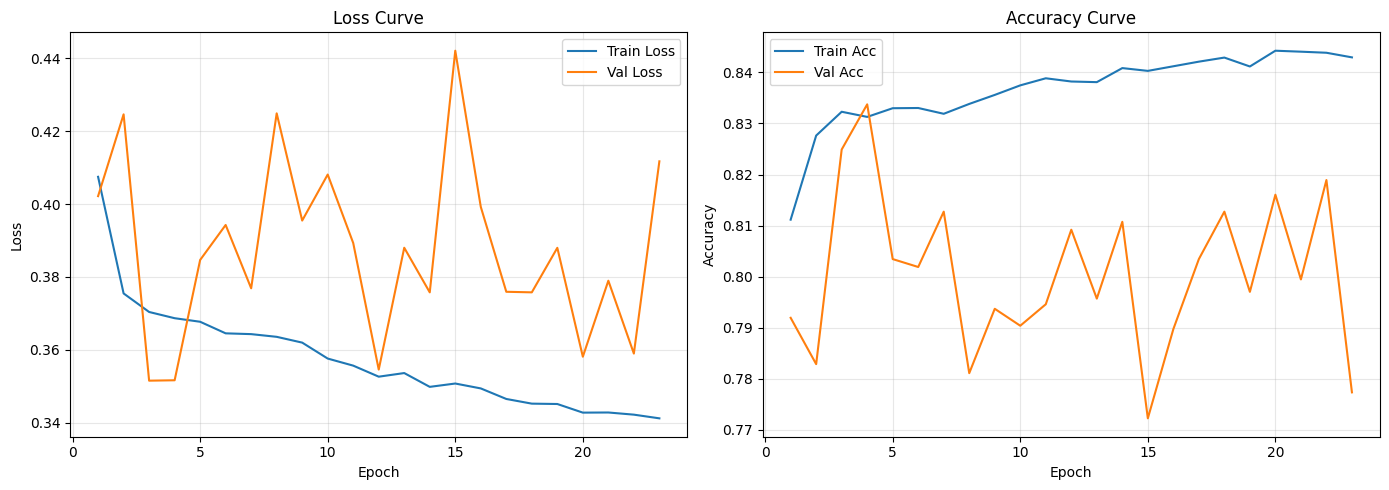

In [26]:
dl.plot_learning_curves(history_mlp)

<!-- @format -->

**Nhận xét:** Model học tốt trên tập train nhưng không cải thiện trên validation, cho thấy dấu hiệu overfitting nhẹ và cần triển khai các phương pháp khác

<!-- @format -->
## 4.5. Đánh giá MLP trên Test set

=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.96      0.74      0.83      6803
        >50K       0.53      0.90      0.67      2242

    accuracy                           0.78      9045
   macro avg       0.74      0.82      0.75      9045
weighted avg       0.85      0.78      0.79      9045

Summary: {'accuracy': 0.7779, 'precision': 0.5308, 'recall': 0.8961, 'f1_score': 0.6667}


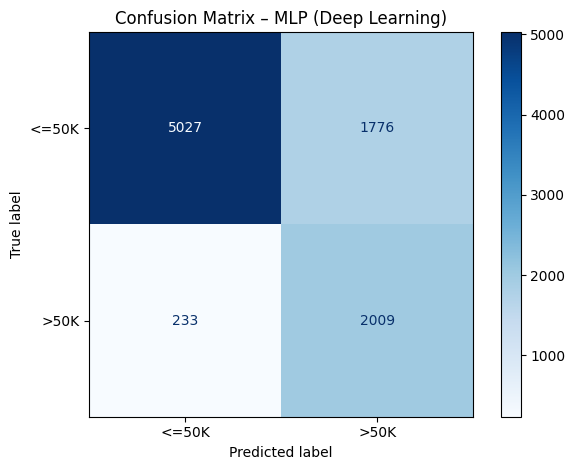

In [27]:
test_metrics_mlp, y_true_mlp, y_pred_mlp, y_proba_mlp = dl.evaluate_model(
    model_mlp, test_loader, device=device
)

<!-- @format -->
## 4.6. So sánh Logistic Regression vs MLP

In [28]:
compare = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP [256, 128, 64]',
        'Accuracy' : test_metrics_mlp['accuracy'],
        'Precision': test_metrics_mlp['precision'],
        'Recall'   : test_metrics_mlp['recall'],
        'F1-Score' : test_metrics_mlp['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_mlp, y_proba_mlp), 4),
    },
])

compare = compare.set_index('Model')
print(compare.to_string())
compare.style.highlight_max(axis=0, color='lightgreen')

                                Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                         
Logistic Regression (baseline)    0.8045     0.5716  0.8443    0.6817   0.9038
MLP [256, 128, 64]                0.7779     0.5308  0.8961    0.6667   0.9064


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804500,0.571600,0.844300,0.681700,0.903800
"MLP [256, 128, 64]",0.777900,0.530800,0.896100,0.666700,0.906400


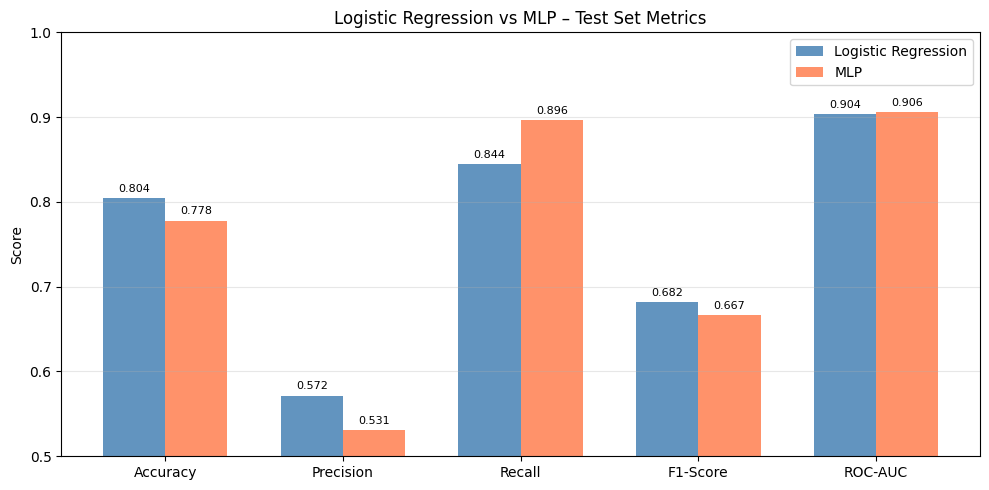

In [29]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare.loc['Logistic Regression (baseline)', metrics_to_plot],
               width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, compare.loc['MLP [256, 128, 64]', metrics_to_plot],
               width, label='MLP', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs MLP – Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- @format -->

**Nhận xét:** MLP cơ bản mà nhóm đề ra không mang lại cải thiện so với Logistic Regression, thậm chí còn kém nhẹ. Do đó nhóm chuyển sang tối ưu siêu tham số với Optuna.

# 5. Tối ưu hoá Siêu tham số với Optuna (Automatic Hyperparameter Tuning)

Tiếp theo, ta sử dụng thư viện **Optuna** để thực hiện quá trình Auto-ML. Công cụ này sẽ tự động chạy thử nhiều cấu hình tham số khác nhau (số lớp, số node, lr, dropout, batch_size...) và tìm ra tập hợp trả về điểm **F1-Score** trên tập Validation cao nhất.

In [30]:
# Thêm các thư viện và hàm cần thiết
import optuna
import copy

class Tuning:
# ─────────────────────────────── Optuna Objective ───────────────────────────
    @staticmethod
    def _optuna_objective(trial, prep, epochs, patience, device):
        """Optuna objective function: train MLP, return val F1."""

        # --- Search space ---
        n_layers = trial.suggest_int("n_layers", 1, 4)
        hidden_dims = []
        for i in range(n_layers):
            dim = trial.suggest_int(f"hidden_dim_{i}", 32, 512, step=32)
            hidden_dims.append(dim)

        dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
        lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
        optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])

        # --- Dataloaders ---
        train_loader, val_loader, _ = dl.create_dataloaders(prep, batch_size=batch_size)

        # --- Model ---
        model = dl.MLP(input_dim=prep["input_dim"], hidden_dims=hidden_dims, dropout=dropout)
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        model = model.to(device)

        # --- Loss (class imbalance) ---
        y_train_all = []
        for _, yb in train_loader:
            y_train_all.append(yb)
        y_train_all = torch.cat(y_train_all)
        class_counts = torch.bincount(y_train_all).float()
        pos_weight = (class_counts[0] / class_counts[1]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        # --- Optimizer ---
        if optimizer_name == "Adam":
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5
        )

        best_val_loss = float("inf")
        best_state = None
        epochs_no_improve = 0

        for epoch in range(1, epochs + 1):
            train_loss, _ = dl.train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, _ = dl.evaluate(model, val_loader, criterion, device)
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                # best_state = model.state_dict().copy()
                best_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            # Pruning: report val F1 mỗi epoch
            model.eval()
            y_true_v, y_pred_v, _ = dl.predict(model, val_loader, device)
            val_f1 = f1_score(y_true_v, y_pred_v)
            trial.report(val_f1, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

            if epochs_no_improve >= patience:
                break

        model.load_state_dict(best_state)
        model.eval()
        y_true_v, y_pred_v, _ = dl.predict(model, val_loader, device)
        return f1_score(y_true_v, y_pred_v)


    # ─────────────────────────────── Run Search ─────────────────────────────────
    @staticmethod
    def run_optuna_search(
        prep: dict,
        n_trials: int = 50,
        epochs: int = 50,
        patience: int = 10,
        device: str = None,
    ):
        """
        Chạy Optuna study để tìm hyperparameters tốt nhất cho MLP.

        Returns
        -------
        optuna.Study
        """
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        study = optuna.create_study(
            direction="maximize",
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
            study_name="MLP-Adult-Income",
        )

        study.optimize(
            lambda trial: _optuna_objective(trial, prep, epochs, patience, device),
            n_trials=n_trials,
            show_progress_bar=True,
        )

        print(f"\n{'='*70}")
        print(f"  OPTUNA SEARCH COMPLETED  ({len(study.trials)} trials)")
        print(f"{'='*70}")
        print(f"  Best Val F1: {study.best_value:.4f}")
        print(f"  Best Params:")
        for k, v in study.best_params.items():
            print(f"    {k}: {v}")

        return study


    # ────────────────────────────── Train Best Model ────────────────────────────
    @staticmethod
    def train_best_optuna_model(
        study,
        prep: dict,
        epochs: int = 50,
        patience: int = 10,
        device: str = None,
    ):
        """
        Train lại mô hình tốt nhất từ Optuna study với đánh giá đầy đủ.

        Đọc best_params từ study, rebuild kiến trúc MLP tốt nhất,
        train từ đầu với đầy đủ epochs rồi đánh giá trên test set.

        Returns
        -------
        (model, history, metrics)
        """
        params = study.best_params

        n_layers = params["n_layers"]
        hidden_dims = [params[f"hidden_dim_{i}"] for i in range(n_layers)]
        dropout = params["dropout"]
        lr = params["lr"]
        weight_decay = params["weight_decay"]
        batch_size = params["batch_size"]
        optimizer_name = params["optimizer"]

        print(f"Training best model: hidden_dims={hidden_dims}, dropout={dropout}")
        print(f"  lr={lr:.6f}, weight_decay={weight_decay:.6f}, batch_size={batch_size}, optimizer={optimizer_name}")

        train_loader, val_loader, test_loader = dl.create_dataloaders(prep, batch_size=batch_size)
        model = MLP(input_dim=prep["input_dim"], hidden_dims=hidden_dims, dropout=dropout)

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        model = model.to(device)

        y_train_all = []
        for _, yb in train_loader:
            y_train_all.append(yb)
        y_train_all = torch.cat(y_train_all)
        class_counts = torch.bincount(y_train_all).float()
        pos_weight = (class_counts[0] / class_counts[1]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        if optimizer_name == "Adam":
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5
        )

        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        best_val_loss = float("inf")
        best_state = None
        epochs_no_improve = 0

        print(f"Training on {device}  |  epochs={epochs}  |  patience={patience}")
        print("-" * 70)

        for epoch in range(1, epochs + 1):
            train_loss, train_acc = dl.train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = dl.evaluate(model, val_loader, criterion, device)
            scheduler.step(val_loss)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                # best_state = model.state_dict().copy()
                best_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                marker = " *"
            else:
                epochs_no_improve += 1
                marker = ""

            if epoch % 5 == 0 or epoch == 1 or marker:
                print(
                    f"Epoch {epoch:3d}/{epochs}  |  "
                    f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  |  "
                    f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}{marker}"
                )

            if epochs_no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

        if best_state is not None:
            model.load_state_dict(best_state)
        model.eval()

        metrics, y_true, y_pred, y_proba = dl.evaluate_model(model, test_loader, device=device)

        return model, history, metrics


    # ─────────────────────────────── Visualization ──────────────────────────────
    @staticmethod
    def plot_optuna_results(study):
        """Trực quan hóa kết quả Optuna: optimization history + param importances."""
        trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if not trials:
            print("Không có trial hoàn thành để vẽ.")
            return

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # 1. Optimization history
        values = [t.value for t in trials]
        best_so_far = np.maximum.accumulate(values)
        axes[0].plot(range(1, len(values) + 1), values, "o-", alpha=0.5, markersize=4, label="Trial F1")
        axes[0].plot(range(1, len(values) + 1), best_so_far, "r-", linewidth=2, label="Best so far")
        axes[0].set_xlabel("Trial")
        axes[0].set_ylabel("Val F1")
        axes[0].set_title("Optuna Optimization History")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # 2. Param importances
        try:
            importances = optuna.importance.get_param_importances(study)
            params = list(importances.keys())
            imp_vals = list(importances.values())
            y_pos = np.arange(len(params))
            axes[1].barh(y_pos, imp_vals, align="center", alpha=0.8)
            axes[1].set_yticks(y_pos)
            axes[1].set_yticklabels(params, fontsize=9)
            axes[1].set_xlabel("Importance")
            axes[1].set_title("Hyperparameter Importances")
            axes[1].grid(True, alpha=0.3, axis="x")
        except Exception as e:
            axes[1].text(0.5, 0.5, f"Cannot compute importances:\n{e}",
                        ha="center", va="center", transform=axes[1].transAxes)
            axes[1].set_title("Hyperparameter Importances (unavailable)")

        plt.tight_layout()
        plt.show()


    # ───────────────────────────── TabNet + Optuna ─────────────────────────────
    @staticmethod
    def _optuna_tabnet_objective(trial, prep_tabnet, max_epochs, patience, device, use_pretraining):
        """Optuna objective function: train TabNet, return val F1."""
        width = trial.suggest_categorical("width", [8, 16, 32, 64])
        n_steps = trial.suggest_int("n_steps", 3, 5)
        gamma = trial.suggest_float("gamma", 1.0, 1.5)
        lambda_sparse = trial.suggest_float("lambda_sparse", 1e-5, 1e-2, log=True)
        lr = trial.suggest_float("lr", 1e-3, 5e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])
        virtual_batch_size = trial.suggest_categorical("virtual_batch_size", [64, 128, 256])

        pretrainer = None
        if use_pretraining:
            pretrain_epochs = trial.suggest_int("pretrain_epochs", 20, 60, step=10)
            pretrain_ratio = trial.suggest_float("pretraining_ratio", 0.6, 0.9)
            pretrainer = dl.pretrain_tabnet(
                prep_tabnet,
                pretrain_epochs=pretrain_epochs,
                batch_size=batch_size,
                virtual_batch_size=min(virtual_batch_size, batch_size),
                pretraining_ratio=pretrain_ratio,
                n_d=width,
                n_a=width,
                n_steps=n_steps,
                gamma=gamma,
                lambda_sparse=lambda_sparse,
                lr=lr,
                device=device,
            )

        tabnet = dl.train_tabnet_model(
            prep_tabnet,
            n_d=width,
            n_a=width,
            n_steps=n_steps,
            gamma=gamma,
            lambda_sparse=lambda_sparse,
            lr=lr,
            max_epochs=max_epochs,
            patience=patience,
            batch_size=batch_size,
            virtual_batch_size=min(virtual_batch_size, batch_size),
            custom_weights=prep_tabnet.get("class_weights"),
            pretrainer=pretrainer,
            device=device,
        )

        y_pred_val = tabnet.predict(prep_tabnet["X_val"])
        y_true_val = prep_tabnet["y_val"]
        val_f1 = f1_score(y_true_val, y_pred_val)
        return val_f1

    @staticmethod
    def run_optuna_search_tabnet(
        prep_tabnet: dict,
        n_trials: int = 20,
        max_epochs: int = 80,
        patience: int = 10,
        device: str = None,
        use_pretraining: bool = True,
    ):
        """
        Chạy Optuna study để tìm hyperparameters tốt nhất cho TabNet.

        Returns
        -------
        optuna.Study
        """
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        study_name = "TabNet-Adult-Income-Pretrain" if use_pretraining else "TabNet-Adult-Income"
        study = optuna.create_study(
            direction="maximize",
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
            study_name=study_name,
        )

        study.optimize(
            lambda trial: _optuna_tabnet_objective(
                trial,
                prep_tabnet,
                max_epochs,
                patience,
                device,
                use_pretraining,
            ),
            n_trials=n_trials,
            show_progress_bar=True,
        )

        print(f"\n{'='*70}")
        print(f"  TABNET OPTUNA SEARCH COMPLETED  ({len(study.trials)} trials)")
        print(f"{'='*70}")
        print(f"  Best Val F1: {study.best_value:.4f}")
        print("  Best Params:")
        for k, v in study.best_params.items():
            print(f"    {k}: {v}")

        return study

    @staticmethod
    def train_best_optuna_tabnet_model(
    study,
    prep_tabnet: dict,
    max_epochs: int = 100,
    patience: int = 10,
    device: str = None,
    use_pretraining: bool = True,
):
        """
        Train lại TabNet tốt nhất từ Optuna study với đánh giá đầy đủ trên test set.

        Returns
        -------
        (tabnet_model, metrics)
        """
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        params = study.best_params
        width = params["width"]
        n_steps = params["n_steps"]
        gamma = params["gamma"]
        lambda_sparse = params["lambda_sparse"]
        lr = params["lr"]
        batch_size = params["batch_size"]
        virtual_batch_size = min(params["virtual_batch_size"], batch_size)

        pretrainer = None
        if use_pretraining and "pretrain_epochs" in params:
            pretrainer = dl.pretrain_tabnet(
                prep_tabnet,
                pretrain_epochs=params["pretrain_epochs"],
                batch_size=batch_size,
                virtual_batch_size=virtual_batch_size,
                pretraining_ratio=params.get("pretraining_ratio", 0.8),
                n_d=width,
                n_a=width,
                n_steps=n_steps,
                gamma=gamma,
                lambda_sparse=lambda_sparse,
                lr=lr,
                device=device,
            )

        tabnet_model = dl.train_tabnet_model(
            prep_tabnet,
            n_d=width,
            n_a=width,
            n_steps=n_steps,
            gamma=gamma,
            lambda_sparse=lambda_sparse,
            lr=lr,
            max_epochs=max_epochs,
            patience=patience,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            custom_weights=prep_tabnet.get("class_weights"),
            pretrainer=pretrainer,
            device=device,
        )

        metrics, _, _, _ = dl.evaluate_tabnet(tabnet_model, prep_tabnet)
        return tabnet_model, metrics

tune = Tuning()

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
print("Bắt đầu tìm kiếm tham số tối ưu bằng Optuna...")
# Ở đây ta dùng bộ dữ liệu KHÔNG có SMOTE nhưng đã chuẩn hoá
prep_tuned = {
    'X_train': X_train_sc.values.astype('float32'),
    'X_val'  : X_val_sc.values.astype('float32'),
    'X_test' : X_test_sc.values.astype('float32'),
    'y_train': y_train.values.astype('int64'),
    'y_val'  : y_val.values.astype('int64'),
    'y_test' : y_test.values.astype('int64'),
    'input_dim': X_train_sc.shape[1],
}
train_loader_tuned, val_loader_tuned, test_loader_tuned = dl.create_dataloaders(prep_tuned, batch_size=256)

def get_mock_study_mlp():
    class MockStudy:
        def __init__(self, best_params):
            self.best_params = best_params
            self.best_value = 0.7049062049062049
    return MockStudy({
        "n_layers": 3,
        "hidden_dim_0": 320,
        "hidden_dim_1": 448,
        "hidden_dim_2": 32,
        "dropout": 0.35,
        "lr": 0.00015193253929678293,
        "weight_decay": 3.0308702059789768e-05,
        "batch_size": 512,
        "optimizer": "AdamW"
    })
study_mlp = get_mock_study_mlp() # Dùng mock study để tiết kiệm thời gian

Bắt đầu tìm kiếm tham số tối ưu bằng Optuna...
DataLoaders created  |  batch_size=256
  Train batches: 124  |  Val batches: 18  |  Test batches: 36


### QUÁ TRÌNH NÀY TỐN TRUNG BÌNH 7-10 PHÚT NÊN ĐƯỢC COMMENT LẠI VÀ CHẠY BẰNG DỮ LIỆU HARDCODE TỪ CÁC LẦN CHẠY TRÊN MÁY SINH VIÊN ĐỂ TIẾT KIỆM THỜI GIAN, BỎ COMMENT PHÍA DƯỚI ĐỂ XEM ĐƯỢC QUÁ TRÌNH CHẠY

In [32]:
# study_mlp = tune.run_optuna_search(
#     prep=prep_tuned, 
#     n_trials=30,  # Có thể tăng số lượng trial lên 50-100 nếu có nhiều thời gian (Tạm để 30 để chạy không quá lâu)
#     epochs=50, 
#     patience=10, 
#     device=device
# )

# # Trực quan hoá lịch sử tìm kiếm và độ quan trọng của các tham số
# tune.plot_optuna_results(study_mlp)

## 5.1. Huấn luyện lại và đánh giá mô hình bằng tham số đỉnh nhất của MLP từ Optuna

Training best model: hidden_dims=[320, 448, 32], dropout=0.35
  lr=0.000152, weight_decay=0.000030, batch_size=512, optimizer=AdamW
DataLoaders created  |  batch_size=512
  Train batches: 62  |  Val batches: 9  |  Test batches: 18
Training on cpu  |  epochs=100  |  patience=15
----------------------------------------------------------------------
Epoch   1/100  |  train_loss=0.7917  train_acc=0.7251  |  val_loss=0.6842  val_acc=0.7471 *
Epoch   2/100  |  train_loss=0.6859  train_acc=0.7507  |  val_loss=0.6418  val_acc=0.7597 *
Epoch   3/100  |  train_loss=0.6523  train_acc=0.7663  |  val_loss=0.6183  val_acc=0.7756 *
Epoch   4/100  |  train_loss=0.6325  train_acc=0.7755  |  val_loss=0.6027  val_acc=0.7774 *
Epoch   5/100  |  train_loss=0.6172  train_acc=0.7821  |  val_loss=0.5901  val_acc=0.7842 *
Epoch   6/100  |  train_loss=0.6030  train_acc=0.7873  |  val_loss=0.5809  val_acc=0.7851 *
Epoch   7/100  |  train_loss=0.5974  train_acc=0.7900  |  val_loss=0.5740  val_acc=0.7904 *
Epoch  

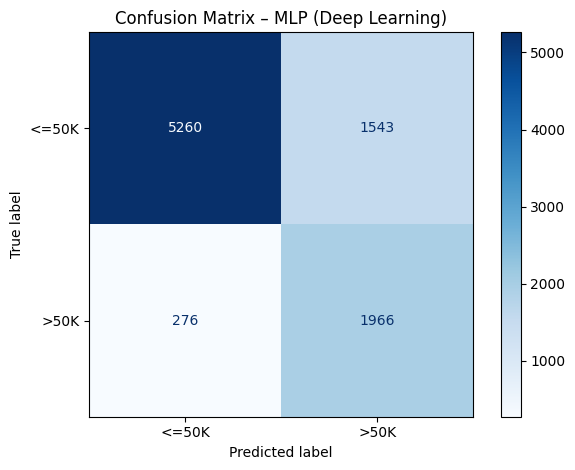

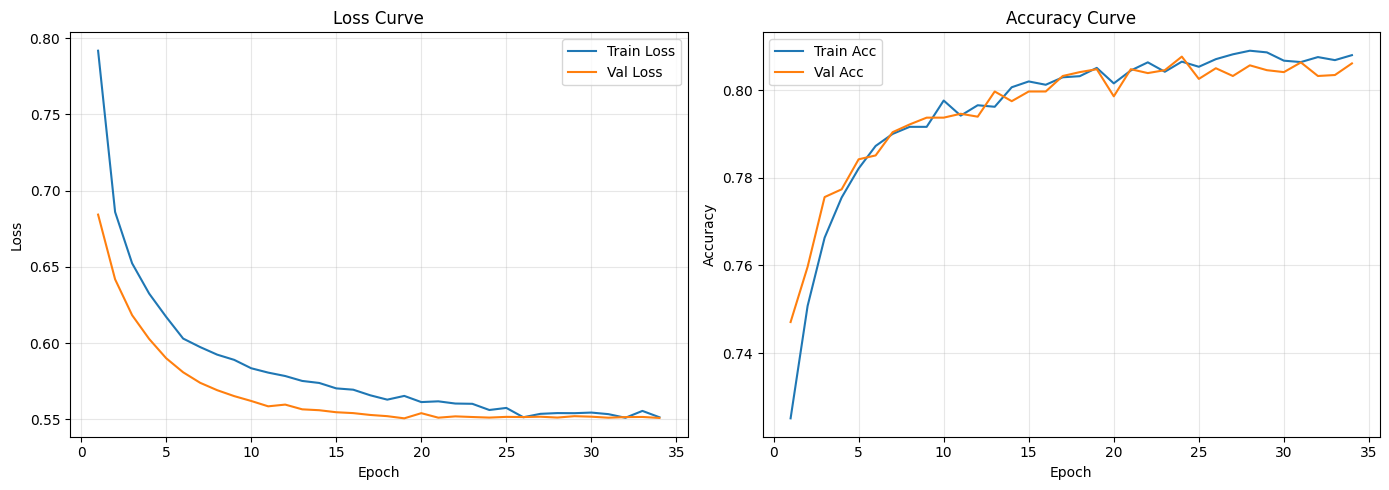

In [33]:
best_model_optuna, best_history_optuna, best_metrics_optuna = tune.train_best_optuna_model(
    study=study_mlp,
    prep=prep_tuned,
    epochs=100,
    patience=15,
    device=device
)

# Vẽ lại learning curve của best model
dl.plot_learning_curves(best_history_optuna)

<!-- @format -->

**Nhận xét:** Model với các siêu tham số mới này đã thể hiện việc học có cải thiện tốt hơn trên tập dữ liệu validation so với các tham số cơ bản ban đầu nhóm đề ra.

## 5.2. So sánh Logistic Regression vs MLP Optuna Best

=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.95      0.77      0.85      6803
        >50K       0.56      0.88      0.68      2242

    accuracy                           0.80      9045
   macro avg       0.76      0.83      0.77      9045
weighted avg       0.85      0.80      0.81      9045

Summary: {'accuracy': 0.7989, 'precision': 0.5603, 'recall': 0.8769, 'f1_score': 0.6837}


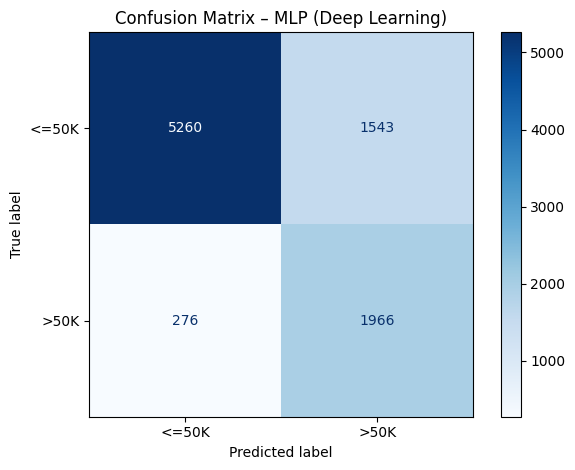

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804500,0.571600,0.844300,0.681700,0.903800
MLP (Optuna Best),0.798900,0.560300,0.876900,0.683700,0.909500


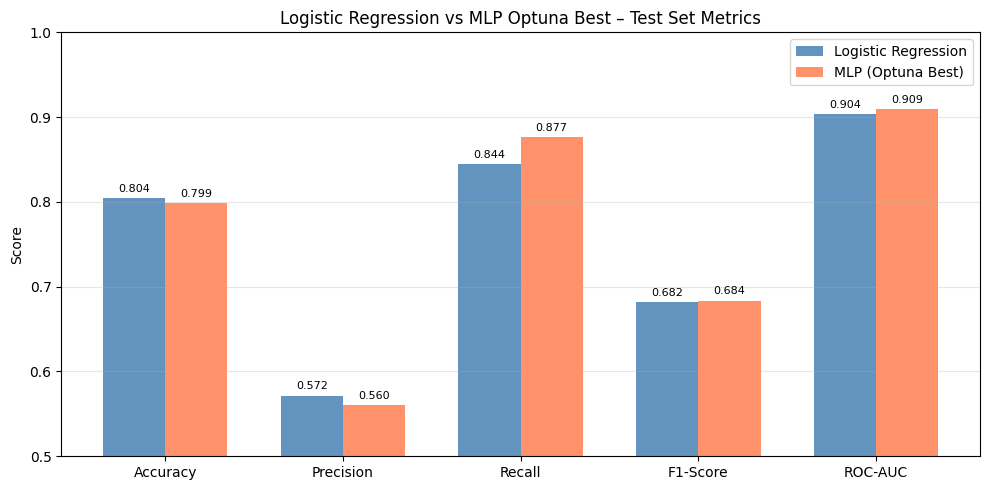

In [34]:
# Lấy dự đoán từ mô hình tốt nhất của Optuna để tính ROC-AUC
_, y_true_optuna, _, y_proba_optuna = dl.evaluate_model(best_model_optuna, test_loader_tuned, device=device)

compare_optuna = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP (Optuna Best)',
        'Accuracy' : best_metrics_optuna['accuracy'],
        'Precision': best_metrics_optuna['precision'],
        'Recall'   : best_metrics_optuna['recall'],
        'F1-Score' : best_metrics_optuna['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_optuna, y_proba_optuna), 4),
    },
])

compare_optuna = compare_optuna.set_index('Model')
display(compare_optuna.style.highlight_max(axis=0, color='lightgreen'))

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare_optuna.loc['Logistic Regression (baseline)', metrics_to_plot],
               width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, compare_optuna.loc['MLP (Optuna Best)', metrics_to_plot],
               width, label='MLP (Optuna Best)', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs MLP Optuna Best – Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- @format -->

**Nhận xét:** MLP đã cải thiện hơn so với Logistic Regression, tuy không nhiều với F1-Score và ROC-AUC nhưng cũng cho thấy hiệu quả trong việc áp dụng Optuna. Tiếp theo nhóm sẽ thử nghiệm trên model TabNet để xem hiệu quả.

# 6. TabNet Model (Attentive Interpretable Tabular Learning)

Sử dụng kiến trúc TabNet được tối ưu hóa đặc biệt cho dữ liệu dạng bảng.
Nhóm quyết định **KHÔNG sử dụng SMOTE** cho TabNet vì mô hình này yêu cầu giữ nguyên tính chất của các biến phân loại (để đưa qua lớp embedding layer) thay vì ép sang dạng One-Hot liên tục sinh bởi SMOTE.

In [35]:
print("--- Chuẩn bị Data gốc cho TabNet ---")
# Đầu vào là df_clean (dataset chuẩn bị ở bước 2.2, chưa qua encode hay smote)
prep_tabnet = dl.preprocess_for_tabnet(
    df_clean, 
    target_col='income', 
    random_state=42
)

print("\nShape của dữ liệu train TabNet (số + phân loại đã mã hóa số nguyên):", prep_tabnet['X_train'].shape)

--- Chuẩn bị Data gốc cho TabNet ---
Rare category grouping (threshold=0.01):
  workclass: 1 rare → 'Other'  (kept 7 categories)
  marital-status: 1 rare → 'Other'  (kept 7 categories)
  occupation: 2 rare → 'Other'  (kept 13 categories)
  race: 2 rare → 'Other'  (kept 4 categories)
  native-country: 39 rare → 'Other'  (kept 3 categories)
  Total rare categories grouped: 45
Encoding mode: TabNet integer categorical + internal embeddings
Num features: 3 | Cat features: 9
cat_idxs: [3, 4, 5, 6, 7, 8, 9, 10, 11]
cat_dims: [8, 8, 14, 7, 5, 3, 4, 5, 4]

Shape của dữ liệu train TabNet (số + phân loại đã mã hóa số nguyên): (28941, 12)


In [36]:
# 2. Train mô hình TabNet
print("\n--- Bắt đầu Training TabNet ---")
tabnet_model = dl.train_tabnet_model(
    prep=prep_tabnet,
    n_d=32,               # Kích thước lớp quyết định
    n_a=32,               # Kích thước lớp chú ý
    n_steps=3,            # Số chặng Attention
    gamma=1.3,
    lr=2e-2,
    max_epochs=100,       
    patience=15,          # Dừng sớm nếu sau 15 epoch val loss không giảm
    batch_size=512,
    virtual_batch_size=128,
    device=device
)


--- Bắt đầu Training TabNet ---
TabNet class weights: {0: 0.6647601984564498, 1: 2.017356754496027}


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.52607 | val_logloss: 1.66226 |  0:00:01s
epoch 1  | loss: 0.44296 | val_logloss: 0.91441 |  0:00:03s
epoch 2  | loss: 0.42004 | val_logloss: 0.49866 |  0:00:04s
epoch 3  | loss: 0.41441 | val_logloss: 0.52867 |  0:00:06s
epoch 4  | loss: 0.4025  | val_logloss: 0.44568 |  0:00:07s
epoch 5  | loss: 0.39922 | val_logloss: 0.40439 |  0:00:08s
epoch 6  | loss: 0.3941  | val_logloss: 0.40259 |  0:00:10s
epoch 7  | loss: 0.39348 | val_logloss: 0.41476 |  0:00:11s
epoch 8  | loss: 0.39263 | val_logloss: 0.43005 |  0:00:13s
epoch 9  | loss: 0.38658 | val_logloss: 0.40167 |  0:00:14s
epoch 10 | loss: 0.38496 | val_logloss: 0.42508 |  0:00:16s
epoch 11 | loss: 0.38241 | val_logloss: 0.39932 |  0:00:17s
epoch 12 | loss: 0.38519 | val_logloss: 0.38615 |  0:00:18s
epoch 13 | loss: 0.38488 | val_logloss: 0.42747 |  0:00:20s
epoch 14 | loss: 0.38411 | val_logloss: 0.36823 |  0:00:21s
epoch 15 | loss: 0.38427 | val_logloss: 0.43398 |  0:00:23s
epoch 16 | loss: 0.38805 | val_logloss: 

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet training complete. Best epoch: 27


=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.93      0.81      0.87      6803
        >50K       0.59      0.82      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.78      9045
weighted avg       0.85      0.81      0.82      9045

Summary: {'accuracy': 0.8118, 'precision': 0.5856, 'recall': 0.8243, 'f1_score': 0.6847}


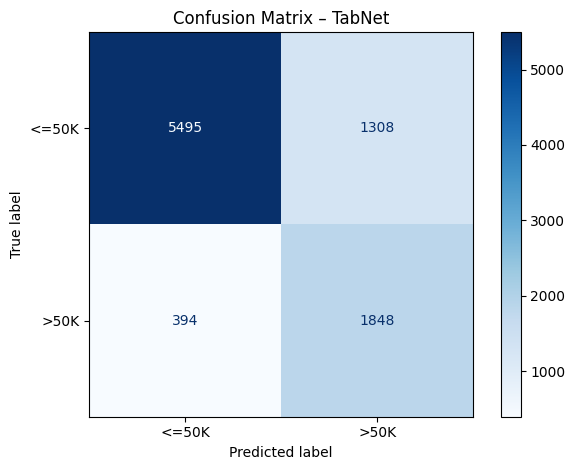

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804500,0.571600,0.844300,0.681700,0.903800
MLP (Optuna Best),0.798900,0.560300,0.876900,0.683700,0.909500
TabNet Basic (No SMOTE),0.811800,0.585600,0.824300,0.684700,0.903400


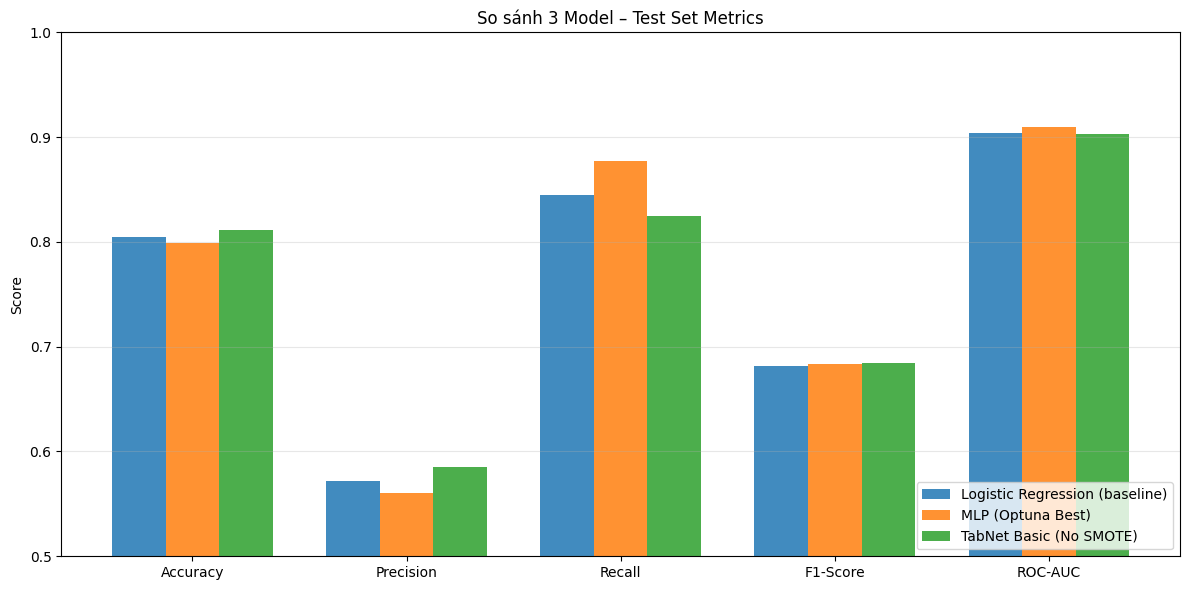

In [37]:
# 3. Đánh giá và So sánh lại với các Baseline trước đó
metrics_tabnet, y_true_tabnet, y_pred_tabnet, y_proba_tabnet = dl.evaluate_tabnet(tabnet_model, prep_tabnet)

compare_all = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP (Optuna Best)',
        'Accuracy' : best_metrics_optuna['accuracy'],
        'Precision': best_metrics_optuna['precision'],
        'Recall'   : best_metrics_optuna['recall'],
        'F1-Score' : best_metrics_optuna['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_optuna, y_proba_optuna), 4),
    },
    {
        'Model'    : 'TabNet Basic (No SMOTE)',
        'Accuracy' : metrics_tabnet['accuracy'],
        'Precision': metrics_tabnet['precision'],
        'Recall'   : metrics_tabnet['recall'],
        'F1-Score' : metrics_tabnet['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_tabnet, y_proba_tabnet), 4),
    },
])

compare_all = compare_all.set_index('Model')
display(compare_all.style.highlight_max(axis=0, color='lightgreen'))

# Trực quan hoá
fig, ax = plt.subplots(figsize=(12, 6))
width_new = 0.25
for i, model_name in enumerate(compare_all.index):
    ax.bar(x + (i - 1) * width_new, compare_all.loc[model_name, metrics_to_plot],
           width_new, label=model_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('So sánh 3 Model – Test Set Metrics')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- @format -->

**Nhận xét:** TabNet với các tham số mà nhóm đưa ra chưa cải thiện được so với MLP, thậm chí còn thấp hơn ở F1-Score. Do đó, nhóm tiếp tục tối ưu siêu tham số của TabNet với Optuna

# 7. Tối ưu hoá Siêu tham số TabNet với Optuna

Chúng ta sẽ sử dụng các hàm đã được gói sẵn trong `modules/tuning_mlp.py` để tìm kiếm siêu tham số và huấn luyện mô hình TabNet tốt nhất. Đặc biệt ở đây còn kèm theo **Cơ chế Pretraining (Self-supervised learning)** tích hợp sẵn.

In [38]:
# 7.1 Thực hiện dò TabNet params
# Sử dụng hàm dò Optuna có sẵn của bạn trong tuning_mlp.py (Đã bật use_pretraining=True mặc định)
def get_mock_study_tabnet(*args, **kwargs):
        class MockStudy:
            def __init__(self, best_params):
                self.best_params = best_params
                self.best_value = 0.6885694729637235
        return MockStudy({
            "width": 8,
            "n_steps": 4,
            "gamma": 1.0137868611216592,
            "lambda_sparse": 0.003924034647132935,
            "lr": 0.007085132090225794,
            "batch_size": 512,
            "virtual_batch_size": 256,
            "pretrain_epochs": 50,
            "pretraining_ratio": 0.6195014675689636
        })
study_tabnet = get_mock_study_tabnet() # Dùng mock study để tiết kiệm thời gian

### QUÁ TRÌNH NÀY TỐN TRUNG BÌNH 30-40 PHÚT NÊN ĐƯỢC COMMENT LẠI VÀ CHẠY BẰNG DỮ LIỆU HARDCODE TỪ CÁC LẦN CHẠY TRÊN MÁY SINH VIÊN ĐỂ TIẾT KIỆM THỜI GIAN, BỎ COMMENT PHÍA DƯỚI ĐỂ XEM ĐƯỢC QUÁ TRÌNH CHẠY

In [39]:
# study_tabnet = tune.run_optuna_search_tabnet(
#     prep_tabnet=prep_tabnet,
#     n_trials=10, 
#     max_epochs=50,
#     patience=10,
#     device=device,
#     use_pretraining=True # Sử dụng pretrain tích hợp sẵn
# )

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.40222 | val_unsup_loss_numpy: 1.1116399765014648|  0:00:01s
epoch 1  | loss: 0.9988  | val_unsup_loss_numpy: 1.029919981956482|  0:00:03s
epoch 2  | loss: 0.9823  | val_unsup_loss_numpy: 1.0514400005340576|  0:00:05s
epoch 3  | loss: 0.96865 | val_unsup_loss_numpy: 1.030460000038147|  0:00:07s
epoch 4  | loss: 0.96313 | val_unsup_loss_numpy: 1.0331499576568604|  0:00:09s
epoch 5  | loss: 0.94035 | val_unsup_loss_numpy: 0.9310399889945984|  0:00:11s
epoch 6  | loss: 0.92639 | val_unsup_loss_numpy: 0.9319300055503845|  0:00:13s
epoch 7  | loss: 0.91174 | val_unsup_loss_numpy: 0.9118599891662598|  0:00:15s
epoch 8  | loss: 0.89947 | val_unsup_loss_numpy: 0.9048399925231934|  0:00:16s
epoch 9  | loss: 0.89997 | val_unsup_loss_numpy: 0.8946700096130371|  0:00:18s
epoch 10 | loss: 0.89232 | val_unsup_loss_numpy: 0.8852699995040894|  0:00:20s
epoch 11 | loss: 0.89234 | val_unsup_loss_numpy: 0.879610002040863|  0:00:22s
epoch 12 | loss: 0.89335 | val_unsup_loss_numpy: 0.8787

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 0.65893 | val_logloss: 0.51096 |  0:00:01s
epoch 1  | loss: 0.4639  | val_logloss: 0.50852 |  0:00:02s
epoch 2  | loss: 0.43144 | val_logloss: 0.46426 |  0:00:03s
epoch 3  | loss: 0.41951 | val_logloss: 0.42215 |  0:00:04s
epoch 4  | loss: 0.4069  | val_logloss: 0.41473 |  0:00:05s
epoch 5  | loss: 0.40413 | val_logloss: 0.42726 |  0:00:05s
epoch 6  | loss: 0.39485 | val_logloss: 0.43032 |  0:00:06s
epoch 7  | loss: 0.39237 | val_logloss: 0.42333 |  0:00:07s
epoch 8  | loss: 0.39485 | val_logloss: 0.40964 |  0:00:08s
epoch 9  | loss: 0.39424 | val_logloss: 0.38467 |  0:00:09s
epoch 10 | loss: 0.39128 | val_logloss: 0.40173 |  0:00:10s
epoch 11 | loss: 0.39238 | val_logloss: 0.42835 |  0:00:11s
epoch 12 | loss: 0.37984 | val_logloss: 0.40173 |  0:00:12s
epoch 13 | loss: 0.37561 | val_logloss: 0.38215 |  0:00:14s
epoch 14 | loss: 0.37713 | val_logloss: 0.42804 |  0:00:14s
epoch 15 | loss: 0.38482 | val_logloss: 0.42498 |  0:00:15s
epoch 16 | loss: 0.37968 | val_logloss: 

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet training complete. Best epoch: 46
=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.92      0.82      0.87      6803
        >50K       0.59      0.80      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.81      0.77      9045
weighted avg       0.84      0.81      0.82      9045

Summary: {'accuracy': 0.8136, 'precision': 0.5922, 'recall': 0.7962, 'f1_score': 0.6792}


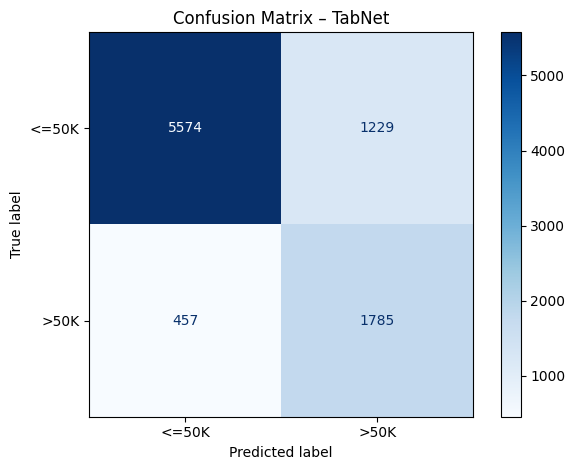

=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.92      0.82      0.87      6803
        >50K       0.59      0.80      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.81      0.77      9045
weighted avg       0.84      0.81      0.82      9045

Summary: {'accuracy': 0.8136, 'precision': 0.5922, 'recall': 0.7962, 'f1_score': 0.6792}


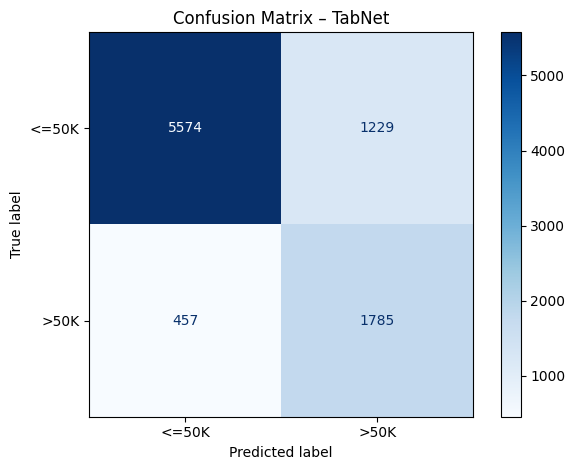

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804500,0.571600,0.844300,0.681700,0.903800
MLP (Optuna Best),0.798900,0.560300,0.876900,0.683700,0.909500
TabNet Basic (No SMOTE),0.811800,0.585600,0.824300,0.684700,0.903400
TabNet (Optuna Best),0.813600,0.592200,0.796200,0.679200,0.901300


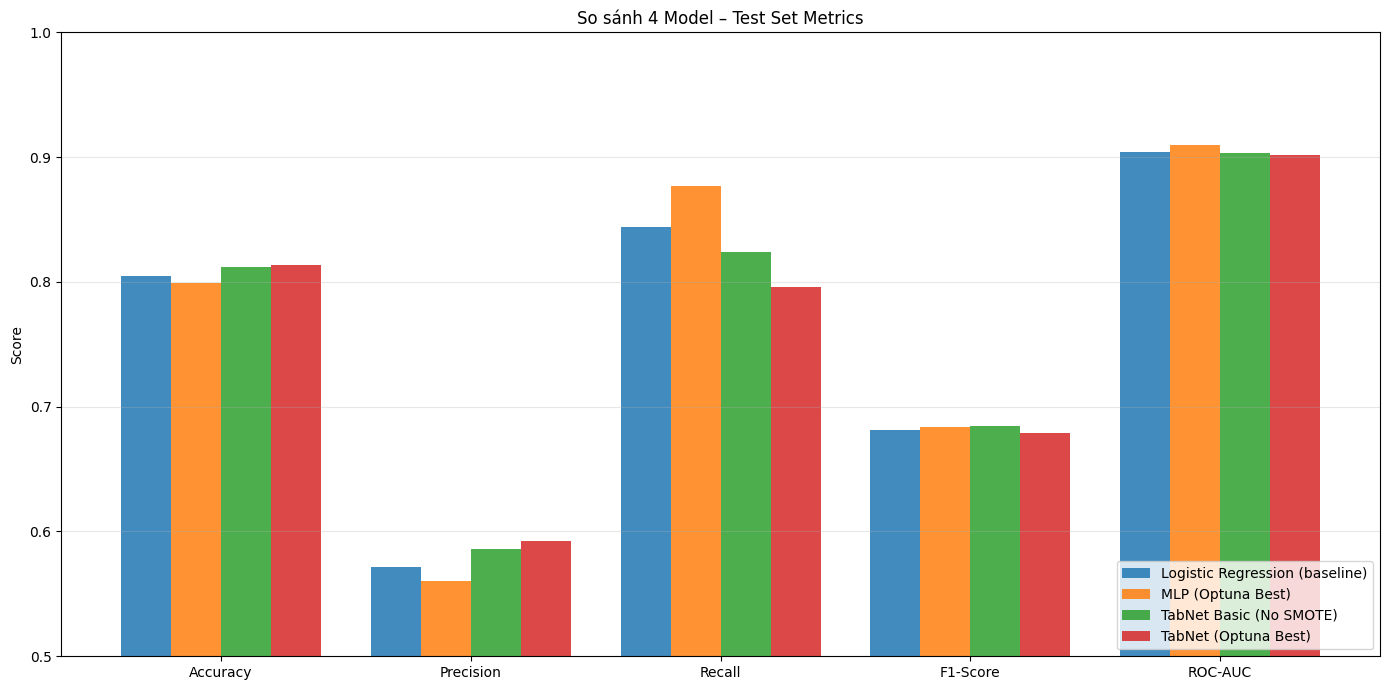

In [40]:
# 7.2 Lấy mô hình có cấu hình tốt nhất và trong tuning_mlp.py
# Hàm `train_best_optuna_tabnet_model` sẽ trả về (model, metrics) nên ta lấy cả hai
best_tabnet_optuna, metrics_tabnet_best = tune.train_best_optuna_tabnet_model(
    study=study_tabnet, 
    prep_tabnet=prep_tabnet, 
    max_epochs=100, 
    patience=15, 
    device=device,
    use_pretraining=True
)

# Để lấy phân loại ROC-AUC, ta dùng predict_proba hoặc chạy lại evaluate
_, y_true_tb, y_pred_tb, y_proba_tb = dl.evaluate_tabnet(best_tabnet_optuna, prep_tabnet)

compare_all.loc['TabNet (Optuna Best)'] = [
    metrics_tabnet_best['accuracy'],
    metrics_tabnet_best['precision'],
    metrics_tabnet_best['recall'],
    metrics_tabnet_best['f1_score'],
    round(roc_auc_score(y_true_tb, y_proba_tb), 4)
]

display(compare_all.style.highlight_max(axis=0, color='lightgreen'))

# Trực quan hoá bản chốt hạ cuối
fig, ax = plt.subplots(figsize=(14, 7))
width_new = 0.2
for i, model_name in enumerate(compare_all.index):
    # Dịch chuyển vị trí các cột
    ax.bar(x + (i - 1.5) * width_new, compare_all.loc[model_name, metrics_to_plot],
           width_new, label=model_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('So sánh 4 Model – Test Set Metrics')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- @format -->

**Nhận xét:** Trên dữ liệu bảng, các mô hình truyền thống như Logistic Regression vẫn cho hiệu năng rất cạnh tranh và ổn định, gần như ngang với các mô hình deep learning. Mặc dù MLP có cải thiện nhẹ ở một số chỉ số, sự khác biệt không đáng kể và không đủ để khẳng định ưu thế vượt trội. Điều này cho thấy deep learning chỉ thực sự phát huy khi có dữ liệu lớn hoặc cấu trúc phức tạp hơn.